# PHÂN TÍCH VÀ TIỀN XỬ LÝ DỮ LIỆU - Pima Indians Diabetes

##  Import các thư viện cần thiết

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập hiển thị đẹp hơn
pd.set_option('display.max_columns', 10)
pd.set_option('display.width', 1000)
sns.set(style="whitegrid")

## Đọc dữ liệu
 Giả sử file tên là: pima-indians-diabetes.csv
 Nếu file nằm ở thư mục khác, thay đổi đường dẫn phù hợp

In [23]:
file_path = 'pima-indians-diabetes.csv'

# Đọc file (không có header trong file gốc)
column_names = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'
]

df = pd.read_csv(file_path, header=None, names=column_names)

## Khám phá dữ liệu cơ bản

In [24]:
print("=== 1. Kích thước dữ liệu ===")
print(df.shape)  # (768, 9)

print("\n=== 2. 5 dòng đầu tiên ===")
print(df.head())

print("\n=== 3. Thông tin tổng quan ===")
print(df.info())

print("\n=== 4. Thống kê mô tả ===")
print(df.describe())

print("\n=== 5. Phân bố biến mục tiêu (Outcome) ===")
print(df['Outcome'].value_counts(normalize=True) * 100)

=== 1. Kích thước dữ liệu ===
(768, 9)

=== 2. 5 dòng đầu tiên ===
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  DiabetesPedigreeFunction  Age  Outcome
0            6      148             72             35        0  33.6                     0.627   50        1
1            1       85             66             29        0  26.6                     0.351   31        0
2            8      183             64              0        0  23.3                     0.672   32        1
3            1       89             66             23       94  28.1                     0.167   21        0
4            0      137             40             35      168  43.1                     2.288   33        1

=== 3. Thông tin tổng quan ===
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null 

## 3.3.1. Kiểm tra và loại bỏ dữ liệu trùng lặp

In [25]:
print("\n=== 6. Kiểm tra dữ liệu trùng lặp ===")
duplicates = df.duplicated().sum()
print(f"Số dòng trùng lặp: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print(f"→ Đã xóa {duplicates} dòng trùng lặp")
else:
    print("→ Không có dòng trùng lặp")


=== 6. Kiểm tra dữ liệu trùng lặp ===
Số dòng trùng lặp: 0
→ Không có dòng trùng lặp


## 3.3.2. Kiểm tra và loại bỏ dữ liệu lỗi, ngoại lệ sinh lý

In [26]:
# Định nghĩa ngưỡng sinh lý hợp lý (rộng để tránh loại bỏ dữ liệu tốt)
physiological_ranges = {
    'Pregnancies': (0, 20),
    'Glucose': (20, 300),
    'BloodPressure': (40, 200),
    'BMI': (10, 80),
    'Age': (21, 100)
}

def detect_physiological_errors(df, ranges):
    """
    Phát hiện các giá trị nằm ngoài ngưỡng sinh lý hợp lý.
    Trả về dictionary chứa thông tin lỗi cho từng cột.
    """
    errors = {}
    for col, (min_val, max_val) in ranges.items():
        if col in df.columns:
            invalid_mask = (df[col] < min_val) | (df[col] > max_val)
            problem_vals = df[invalid_mask][col].unique().tolist()
            errors[col] = {
                'count': invalid_mask.sum(),
                'min_actual': df[col].min(),
                'max_actual': df[col].max(),
                'problem_values': problem_vals if len(problem_vals) <= 5 else problem_vals[:5] + ['...']
            }
    return errors

# Thực hiện kiểm tra
print("=== DỮ LIỆU LỖI / NGOẠI LỆ SINH LÝ PHÁT HIỆN ===")
physiological_errors = detect_physiological_errors(df, physiological_ranges)

for col, info in physiological_errors.items():
    print(f"{col}: {info['count']} giá trị lỗi")
    print(f" - Range thực tế: {info['min_actual']} – {info['max_actual']}")
    if info['problem_values']:
        print(f" - Giá trị có vấn đề: {info['problem_values']}")
    print()

=== DỮ LIỆU LỖI / NGOẠI LỆ SINH LÝ PHÁT HIỆN ===
Pregnancies: 0 giá trị lỗi
 - Range thực tế: 0 – 17

Glucose: 5 giá trị lỗi
 - Range thực tế: 0 – 199
 - Giá trị có vấn đề: [0]

BloodPressure: 39 giá trị lỗi
 - Range thực tế: 0 – 122
 - Giá trị có vấn đề: [0, 30, 24, 38]

BMI: 11 giá trị lỗi
 - Range thực tế: 0.0 – 67.1
 - Giá trị có vấn đề: [0.0]

Age: 0 giá trị lỗi
 - Range thực tế: 21 – 81



## 3.3.3. Xử lý giá trị thiếu và giá trị bằng 0

In [27]:
def handle_zero_values(df):
    """
    Xử lý giá trị 0 bất thường trong các cột sinh học nhạy cảm.
    Thay thế bằng median của cột (chỉ tính trên giá trị > 0).
    """
    zero_sensitive_columns = ['Insulin', 'SkinThickness']
    
    for col in zero_sensitive_columns:
        zero_mask = df[col] == 0
        if zero_mask.any():
            count_zeros = zero_mask.sum()
            print(f"Phát hiện {count_zeros} giá trị 0 trong {col}")
            
            # Tính median từ các giá trị hợp lệ (> 0)
            median_val = df[df[col] > 0][col].median()
            df.loc[zero_mask, col] = median_val
            print(f" → Đã thay thế bằng median: {median_val:.2f}")
    
    return df

# Áp dụng xử lý
print("\n=== XỬ LÝ GIÁ TRỊ 0 BẤT THƯỜNG ===")
df_clean = handle_zero_values(df.copy())  # copy để không thay đổi df gốc nếu cần

# Kiểm tra lại số giá trị 0 sau xử lý
print("\nSau xử lý:")
for col in ['Insulin', 'SkinThickness']:
    zeros_left = (df_clean[col] == 0).sum()
    print(f"{col}: còn {zeros_left} giá trị 0")


=== XỬ LÝ GIÁ TRỊ 0 BẤT THƯỜNG ===
Phát hiện 374 giá trị 0 trong Insulin
 → Đã thay thế bằng median: 125.00
Phát hiện 227 giá trị 0 trong SkinThickness
 → Đã thay thế bằng median: 29.00

Sau xử lý:
Insulin: còn 0 giá trị 0
SkinThickness: còn 0 giá trị 0


## 3.3.4. Kết quả sau tiền xử lý

In [32]:
df_final = df 
print("=== KẾT QUẢ SAU XỬ LÝ ===")
print(f"Dữ liệu gốc: {len(df)} dòng")
print(f"Sau xử lý: {len(df_final)} dòng")
print(f"Tỷ lệ giữ lại: {len(df_final)/len(df)*100:.1f}%")

# Kiểm tra lại ngưỡng sinh lý
final_errors = detect_physiological_errors(df_final, physiological_ranges)
if not final_errors:
    print("✔ Tất cả dữ liệu đều trong ngưỡng sinh lý hợp lý")
else:
    print("× Vẫn còn dữ liệu lỗi:")
    for col, info in final_errors.items():
        print(f" - {col}: {info['count']} lỗi")

=== KẾT QUẢ SAU XỬ LÝ ===
Dữ liệu gốc: 768 dòng
Sau xử lý: 768 dòng
Tỷ lệ giữ lại: 100.0%
× Vẫn còn dữ liệu lỗi:
 - Pregnancies: 0 lỗi
 - Glucose: 5 lỗi
 - BloodPressure: 39 lỗi
 - BMI: 11 lỗi
 - Age: 0 lỗi


## In thống kê

In [34]:
import pandas as pd

# Tính thống kê mô tả
stats = df_final.describe().T

# Lấy các chỉ số cần: mean, std, min, max, median
stats_table = stats[['mean', 'std', 'min', 'max']].copy()
stats_table['median'] = df_final.median(numeric_only=True)

# Làm tròn 2 chữ số thập phân
stats_table = stats_table.round(2)

# In bảng giống định dạng mẫu
print("   Biến số                        mean    std     min     max     median")
print("   -----------------------------------------------------------------------")

for var in stats_table.index:
    if var == 'Outcome':
        continue  # in Outcome riêng ở dưới
    row = stats_table.loc[var]
    print(f"   {var:<30} {row['mean']:>6.2f}  {row['std']:>6.2f}  {row['min']:>6.2f}  {row['max']:>7.2f}  {row['median']:>7.2f}")

# In Outcome riêng (vì là binary)
outcome_row = stats_table.loc['Outcome']
print(f"   Outcome                        {outcome_row['mean']:>6.2f}  {outcome_row['std']:>6.2f}  {outcome_row['min']:>6.2f}  {outcome_row['max']:>7.2f}  {outcome_row['median']:>7.2f}")

   Biến số                        mean    std     min     max     median
   -----------------------------------------------------------------------
   Pregnancies                      3.85    3.37    0.00    17.00     3.00
   Glucose                        120.89   31.97    0.00   199.00   117.00
   BloodPressure                   69.11   19.36    0.00   122.00    72.00
   SkinThickness                   20.54   15.95    0.00    99.00    23.00
   Insulin                         79.80  115.24    0.00   846.00    30.50
   BMI                             31.99    7.88    0.00    67.10    32.00
   DiabetesPedigreeFunction         0.47    0.33    0.08     2.42     0.37
   Age                             33.24   11.76   21.00    81.00    29.00
   Outcome                          0.35    0.48    0.00     1.00     0.00


# Chương 4: Phân tích khám phá dữ liệu 

## 4.1 Phân tích đơn biến

4.1.1 Phân bố của từng biến số 

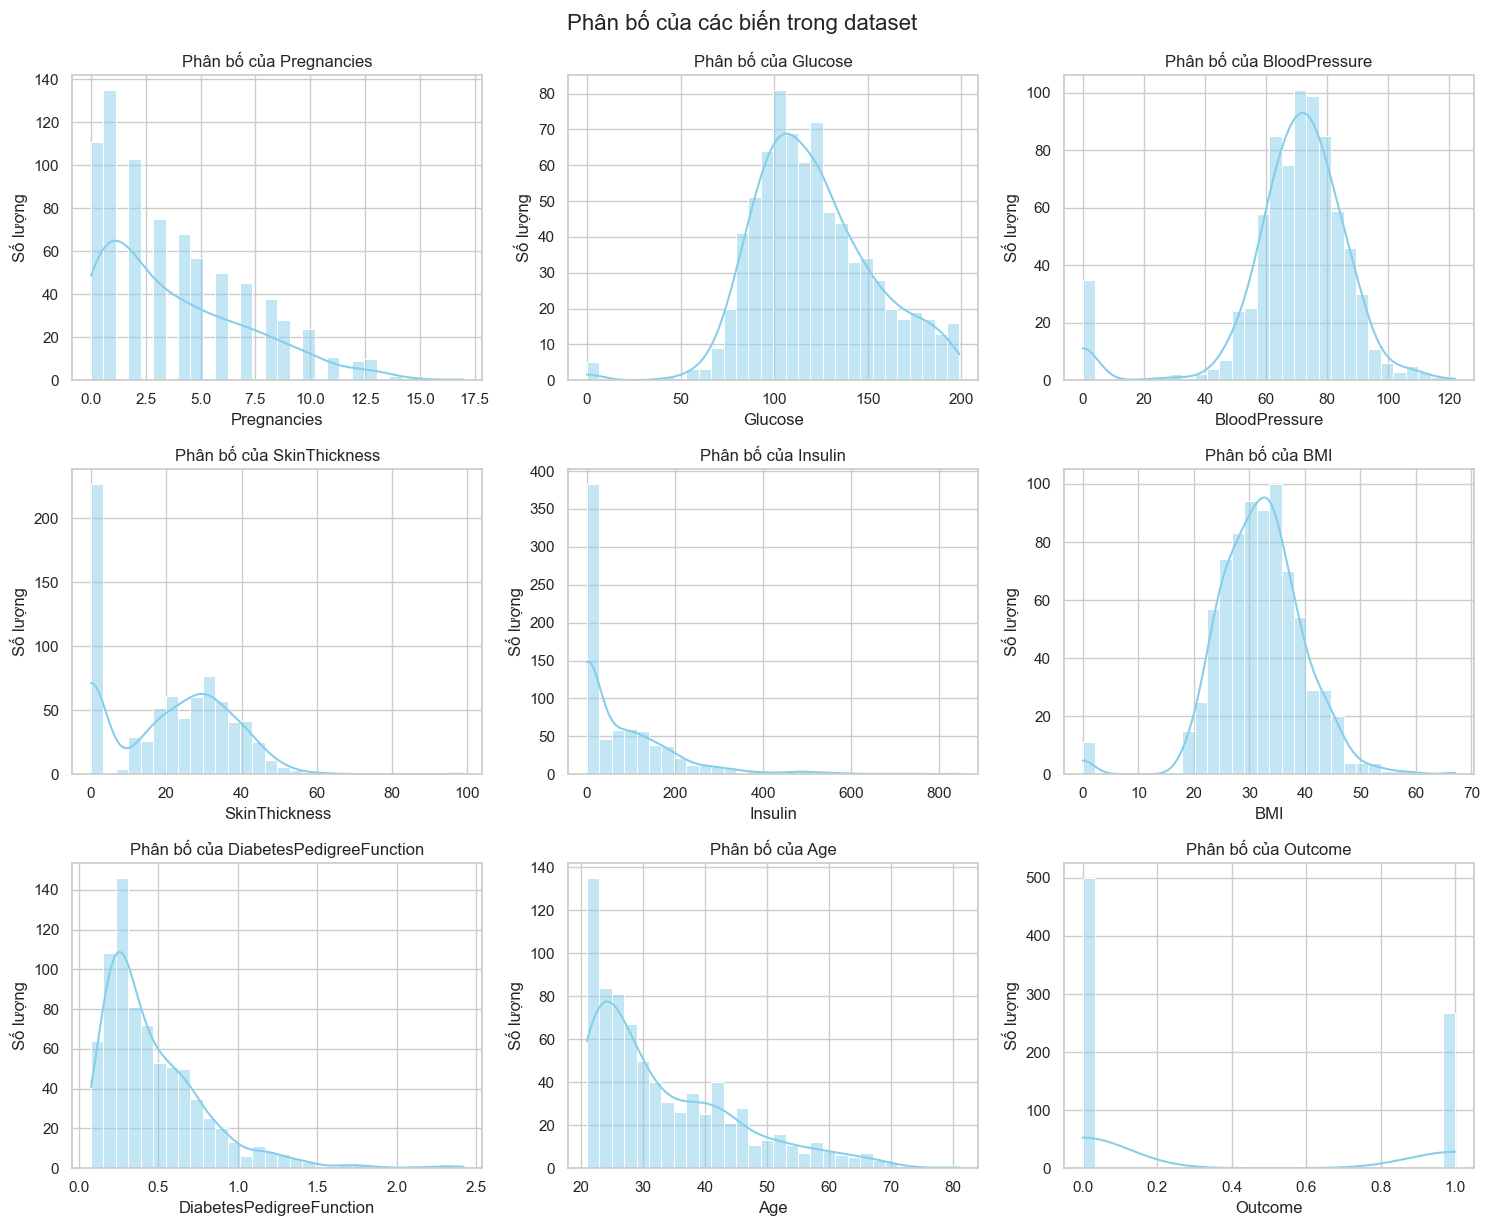

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Giả sử df_final là bộ dữ liệu sạch cuối cùng
# Nếu tên biến khác, thay df_final bằng tên thực tế của bạn

# Danh sách các cột cần vẽ histogram
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
           'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

# Thiết lập figure với lưới 3x3 (9 biểu đồ)
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()  # Chuyển thành mảng 1 chiều để dễ loop

for i, col in enumerate(columns):
    sns.histplot(data=df_final, x=col, kde=True, ax=axes[i], color='skyblue', bins=30)
    axes[i].set_title(f'Phân bố của {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Số lượng')

# Xóa các ô thừa nếu có (nếu ít hơn 9 cột)
for j in range(len(columns), 9):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Phân bố của các biến trong dataset', fontsize=16, y=1.02)
plt.show()

4.1.2 Phát hiện ngoại lệ và bất thường 

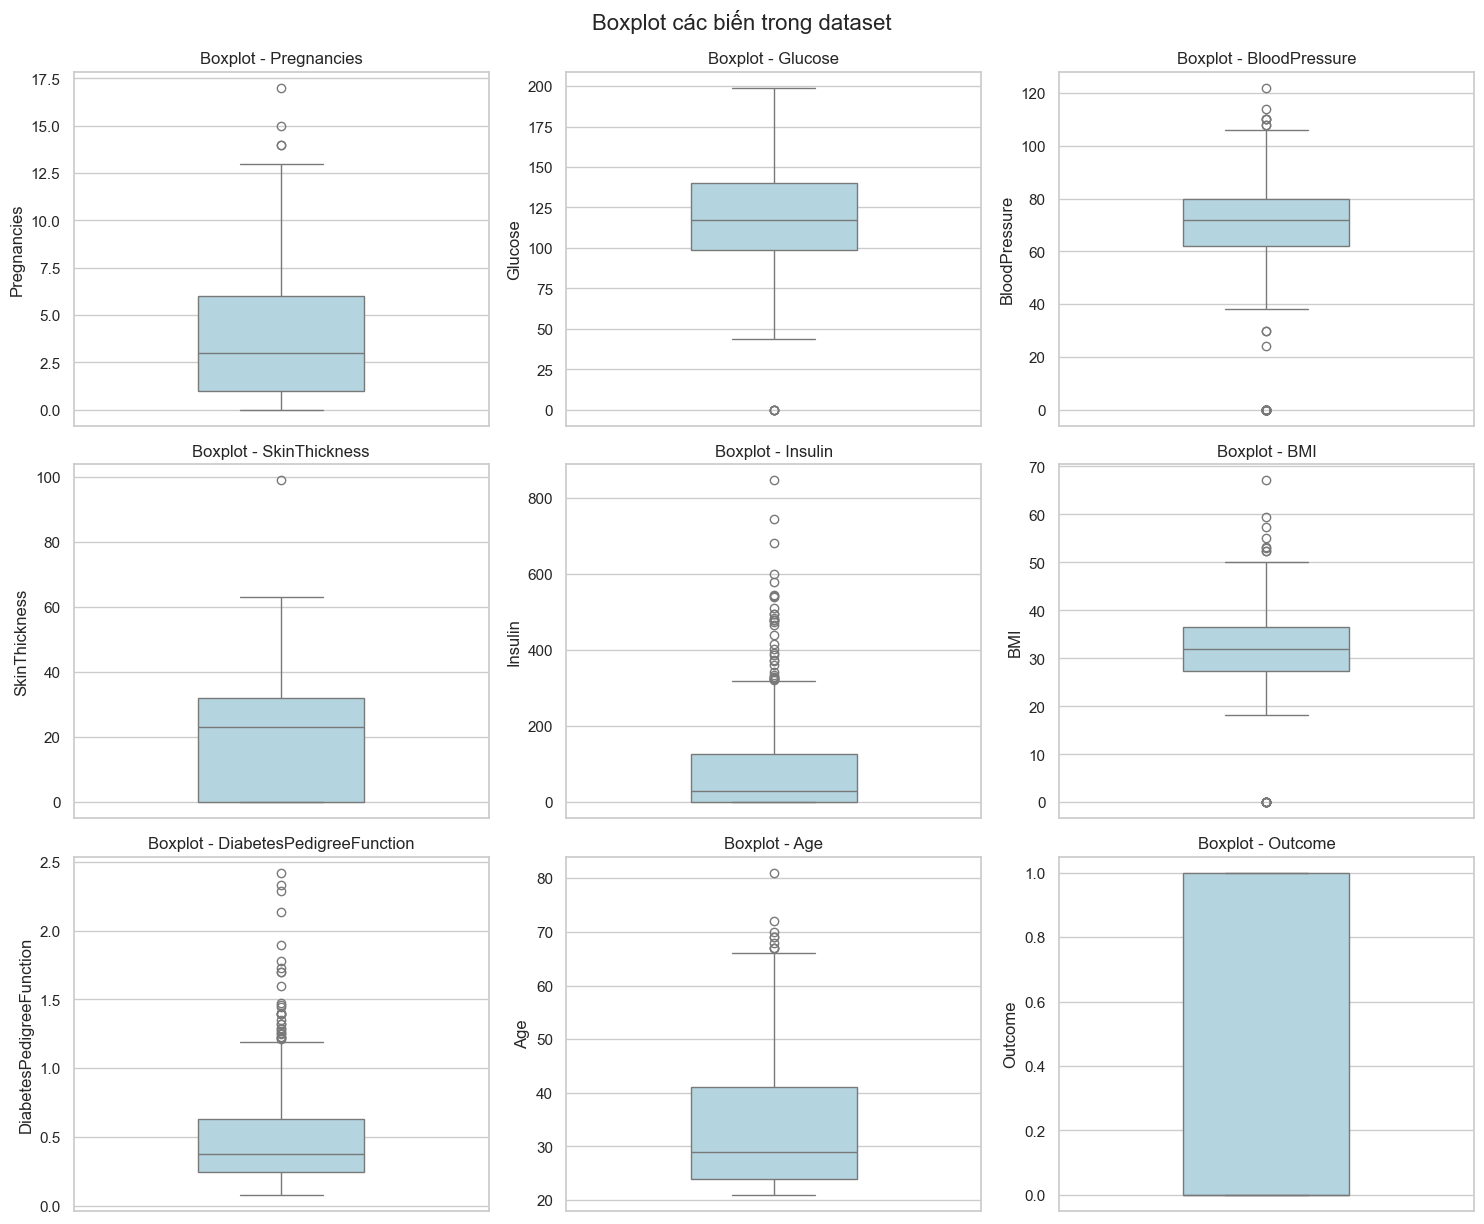

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Giả sử df_final là bộ dữ liệu sạch cuối cùng
# Nếu tên biến khác, thay df_final bằng tên thực tế

# Danh sách các cột cần vẽ boxplot
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
           'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

# Thiết lập figure 3x3
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(columns):
    sns.boxplot(y=df_final[col], ax=axes[i], color='lightblue', width=0.4)
    axes[i].set_title(f'Boxplot - {col}')
    axes[i].set_ylabel(col)

# Xóa ô thừa nếu cần
for j in range(len(columns), 9):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Boxplot các biến trong dataset', fontsize=16, y=1.02)
plt.show()

## 4.2. Phân tích biến mục tiêu 

4.2.1. Tỷ lệ mắc bệnh đái tháo đường trong dataset

C:\Users\Administrator\AppData\Local\Temp\ipykernel_11164\2772526419.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=outcome_counts.index, y=outcome_counts.values, palette=['lightgreen', 'salmon'])


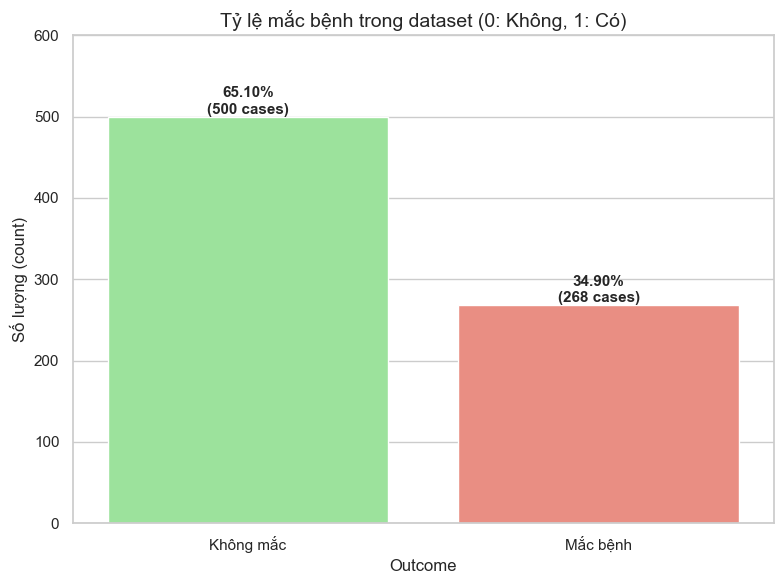

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Giả sử df_final là bộ dữ liệu sạch cuối cùng
# Nếu tên biến khác, thay df_final bằng tên thực tế

# Tính tỷ lệ
outcome_counts = df_final['Outcome'].value_counts()
outcome_percent = outcome_counts / len(df_final) * 100

# Vẽ biểu đồ cột
plt.figure(figsize=(8, 6))
bars = sns.barplot(x=outcome_counts.index, y=outcome_counts.values, palette=['lightgreen', 'salmon'])

# Thêm nhãn phần trăm lên đầu cột
for bar, percent in zip(bars.patches, outcome_percent):
    bars.annotate(f'{percent:.2f}%\n({int(bar.get_height())} cases)',
                  (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                  ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Tỷ lệ mắc bệnh trong dataset (0: Không, 1: Có)', fontsize=14)
plt.xlabel('Outcome')
plt.ylabel('Số lượng (count)')
plt.xticks([0, 1], ['Không mắc', 'Mắc bệnh'])
plt.ylim(0, max(outcome_counts) * 1.2)  # Để chỗ cho nhãn phần trăm

plt.tight_layout()
plt.show()

4.2.2. Đặc điểm nhóm bệnh nhân và nhóm khỏe mạnh

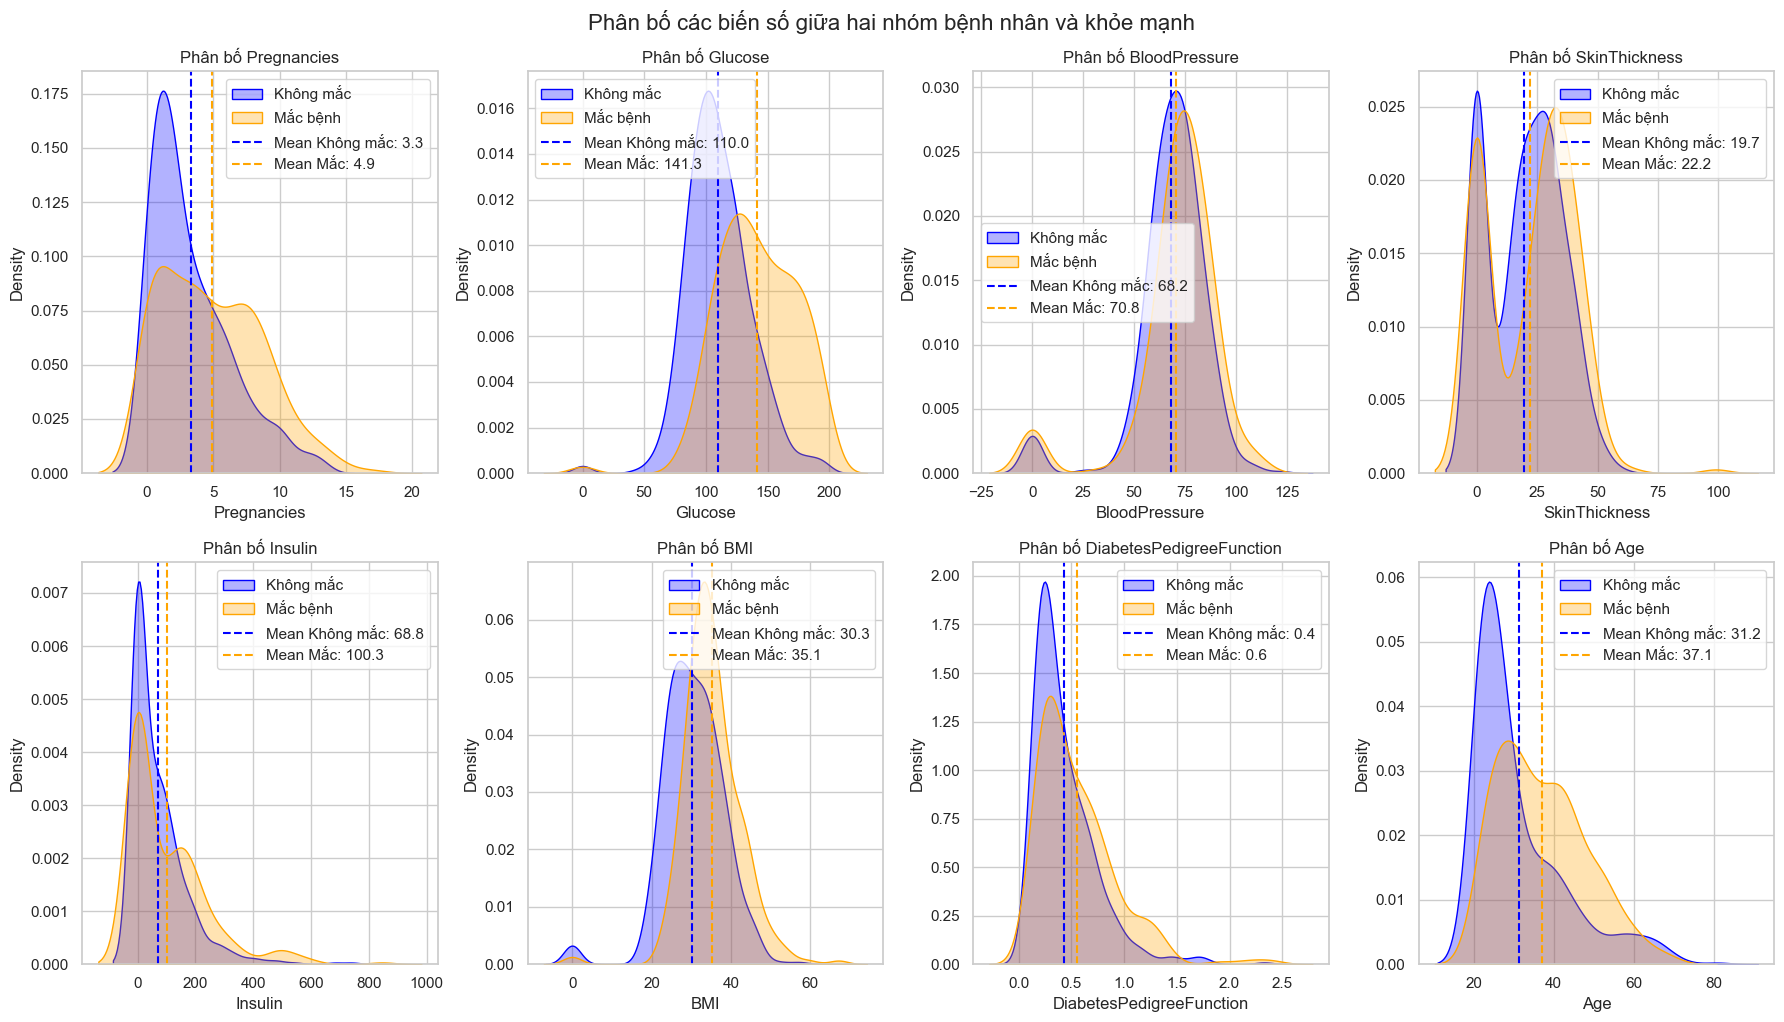

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Giả sử df_final là bộ dữ liệu sạch cuối cùng
# Nếu tên biến khác, thay df_final bằng tên thực tế

columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
           'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

# Thiết lập lưới 2x4 (8 biểu đồ)
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(columns):
    # Vẽ density plot theo nhóm Outcome
    sns.kdeplot(data=df_final[df_final['Outcome'] == 0], x=col, ax=axes[i], 
                color='blue', fill=True, alpha=0.3, label='Không mắc')
    sns.kdeplot(data=df_final[df_final['Outcome'] == 1], x=col, ax=axes[i], 
                color='orange', fill=True, alpha=0.3, label='Mắc bệnh')
    
    # Thêm đường mean
    mean_no = df_final[df_final['Outcome'] == 0][col].mean()
    mean_yes = df_final[df_final['Outcome'] == 1][col].mean()
    axes[i].axvline(mean_no, color='blue', linestyle='--', label=f'Mean Không mắc: {mean_no:.1f}')
    axes[i].axvline(mean_yes, color='orange', linestyle='--', label=f'Mean Mắc: {mean_yes:.1f}')
    
    axes[i].set_title(f'Phân bố {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].legend()

# Xóa ô thừa nếu có
for j in range(len(columns), 8):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Phân bố các biến số giữa hai nhóm bệnh nhân và khỏe mạnh', fontsize=16, y=1.02)
plt.show()

## 4.3 phân tích theo nhóm tuổi 

4.3.1. Phân bố bệnh theo độ tuổi

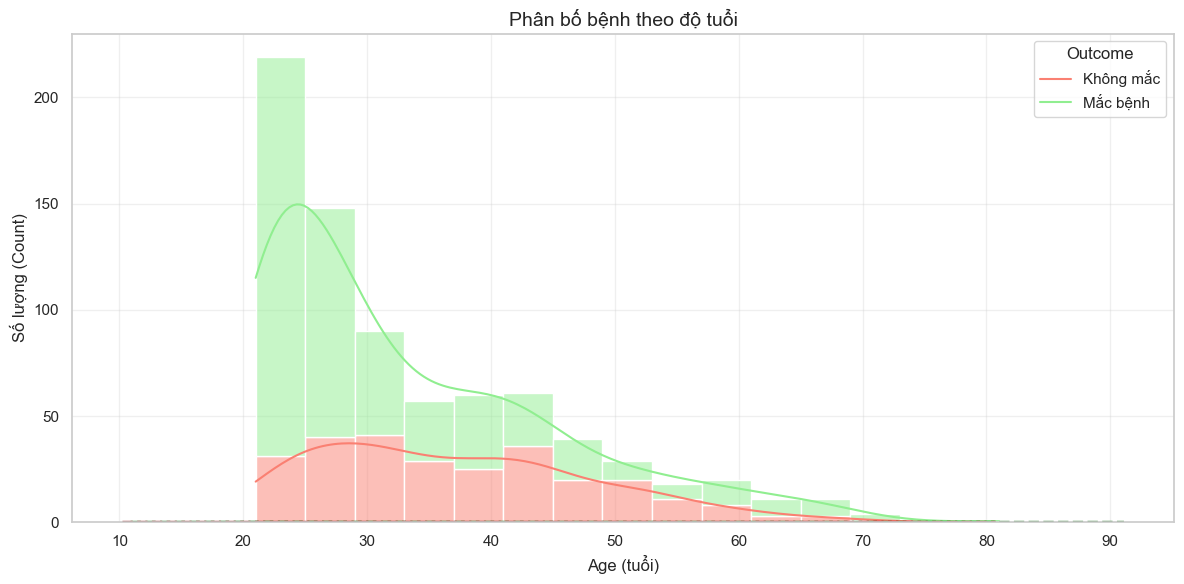

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Giả sử df_final là bộ dữ liệu sạch cuối cùng

# Vẽ biểu đồ phân bố theo tuổi theo Outcome
plt.figure(figsize=(12, 6))
sns.histplot(data=df_final, x='Age', hue='Outcome', multiple='stack', 
             palette=['lightgreen', 'salmon'], bins=15, kde=True)

# Thêm đường KDE riêng cho từng nhóm (tùy chọn)
sns.kdeplot(data=df_final[df_final['Outcome'] == 0], x='Age', color='darkgreen', 
            linestyle='--', linewidth=2, label='Không mắc (KDE)')
sns.kdeplot(data=df_final[df_final['Outcome'] == 1], x='Age', color='darkred', 
            linestyle='--', linewidth=2, label='Mắc bệnh (KDE)')

plt.title('Phân bố bệnh theo độ tuổi', fontsize=14)
plt.xlabel('Age (tuổi)')
plt.ylabel('Số lượng (Count)')
plt.legend(title='Outcome', labels=['Không mắc', 'Mắc bệnh'])
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

4.3.2. Các chỉ số sinh lý thay đổi theo tuổi

BMI theo tuổi

C:\Users\Administrator\AppData\Local\Temp\ipykernel_11164\2758150213.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=age_bins, y=df_final['BMI'], ax=axes[0, 1], palette='Blues')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_11164\2758150213.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=age_bins, y=df_final['Glucose'], ax=axes[1, 1], palette='Oranges')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_11164\2758150213.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=age_bins, y=df_final['BloodPressure'], ax=axes[

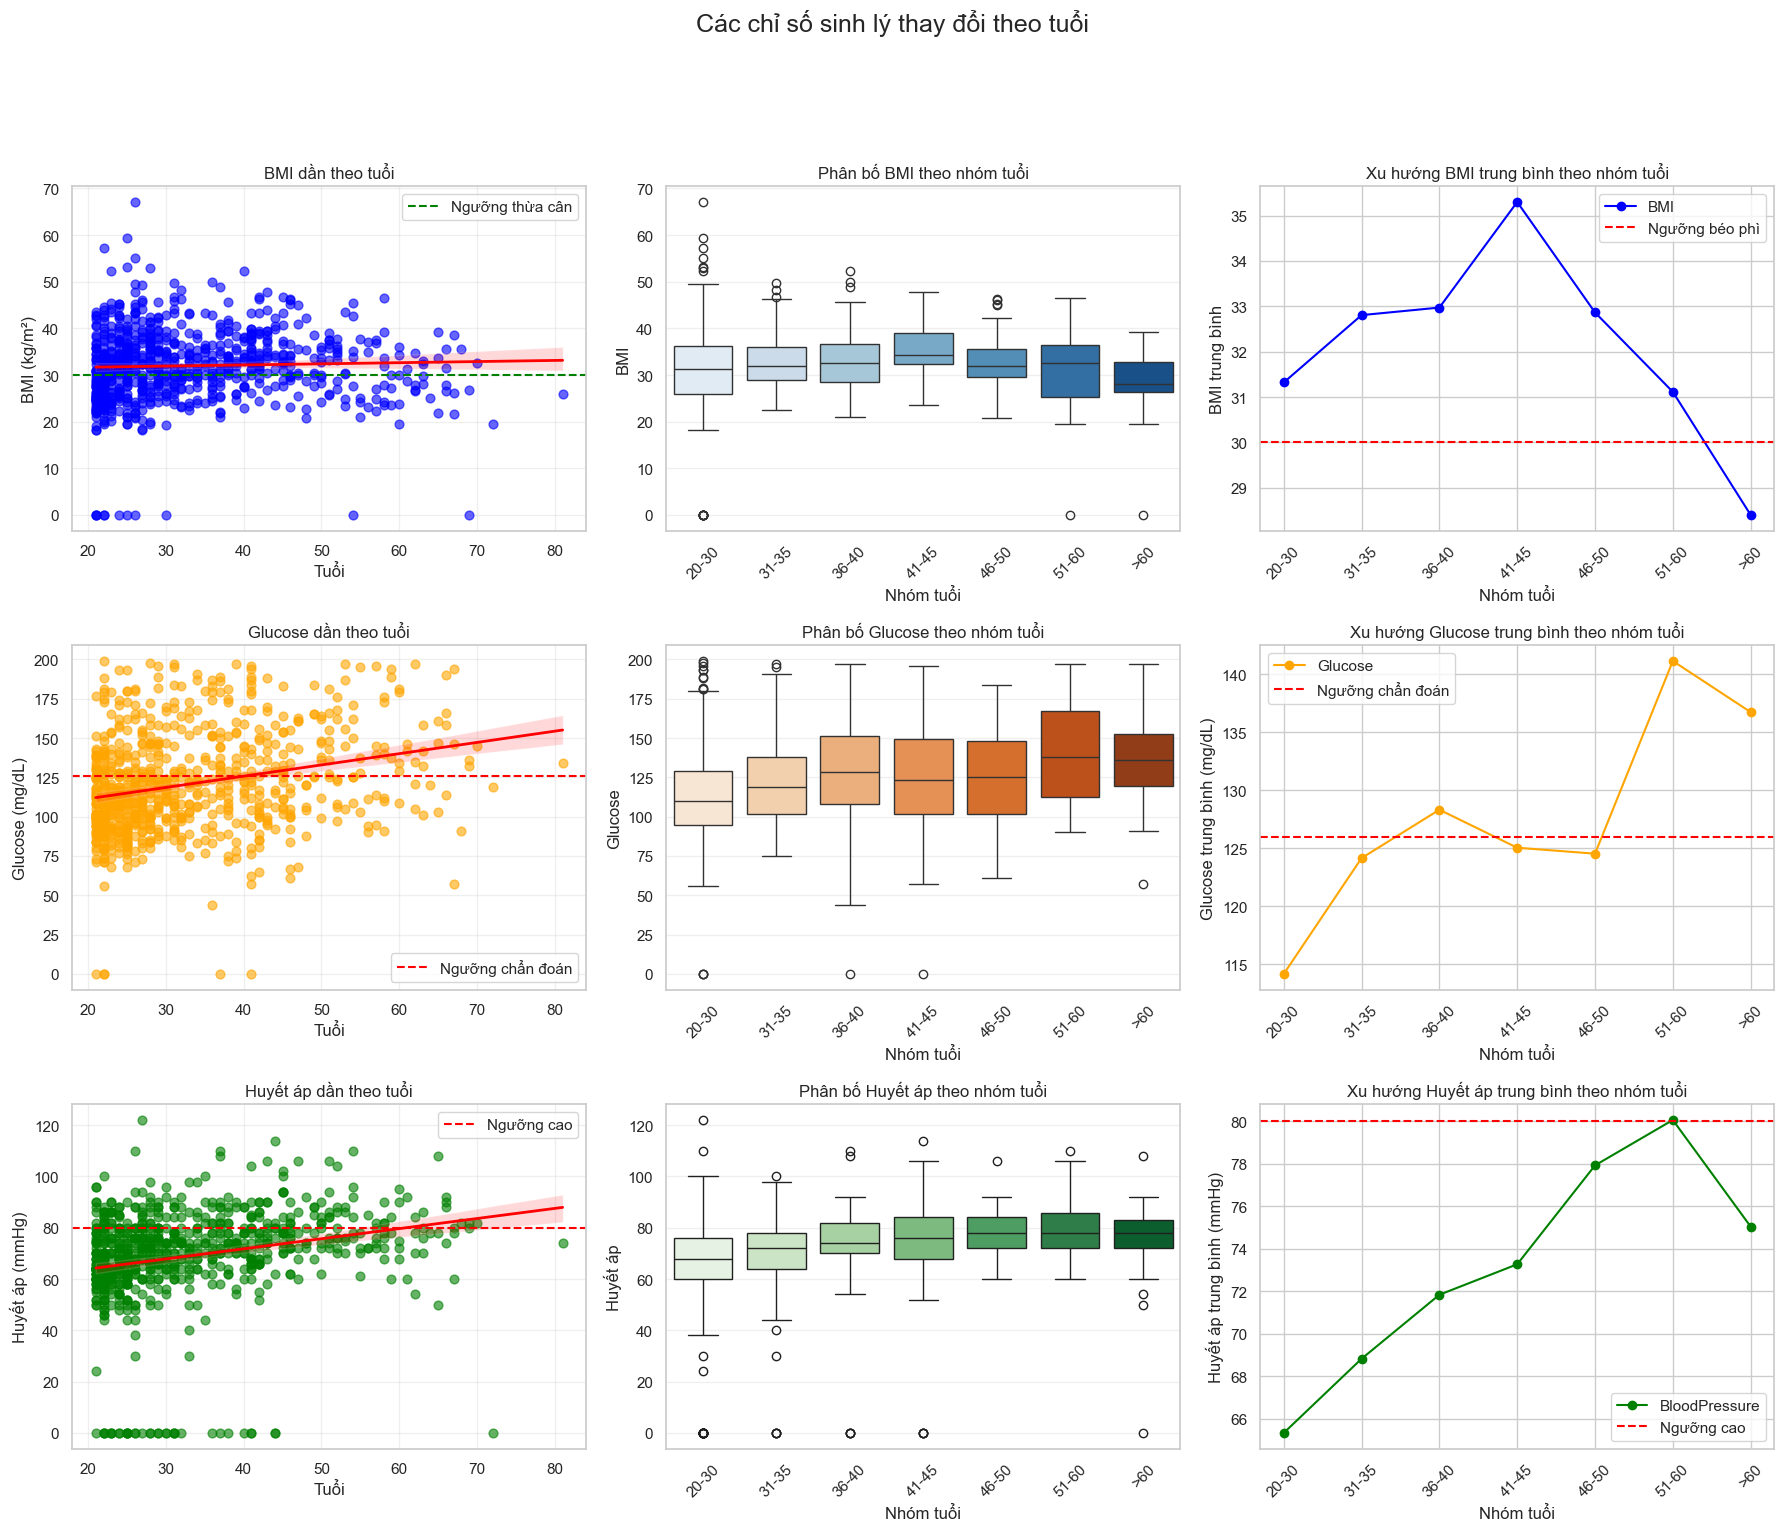

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Giả sử df_final là bộ dữ liệu sạch của bạn (có cột 'Age', 'BMI', 'Glucose', 'BloodPressure')
# Nếu tên DataFrame khác, thay df_final bằng tên thực tế

# Tạo nhóm tuổi (có thể chỉnh khoảng nếu cần)
age_bins = pd.cut(df_final['Age'], bins=[20, 30, 35, 40, 45, 50, 60, 81],
                   labels=['20-30', '31-35', '36-40', '41-45', '46-50', '51-60', '>60'])

# Tạo figure lớn với 3 hàng × 3 cột
fig, axes = plt.subplots(3, 3, figsize=(18, 15), sharex=False, sharey=False)

# ----------------- HÀNG 1: BMI THEO TUỔI -----------------
# 1.1 Scatter + trend line
sns.regplot(x='Age', y='BMI', data=df_final, ax=axes[0, 0],
            scatter_kws={'alpha':0.6, 'color':'blue', 's':40},
            line_kws={'color':'red', 'linewidth':2})
axes[0, 0].set_title('BMI dần theo tuổi')
axes[0, 0].set_xlabel('Tuổi')
axes[0, 0].set_ylabel('BMI (kg/m²)')
axes[0, 0].axhline(30, color='green', linestyle='--', label='Ngưỡng thừa cân')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 1.2 Boxplot theo nhóm tuổi
sns.boxplot(x=age_bins, y=df_final['BMI'], ax=axes[0, 1], palette='Blues')
axes[0, 1].set_title('Phân bố BMI theo nhóm tuổi')
axes[0, 1].set_xlabel('Nhóm tuổi')
axes[0, 1].set_ylabel('BMI')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 1.3 Line xu hướng trung bình
df_final.groupby(age_bins)['BMI'].mean().plot(kind='line', marker='o', color='blue', ax=axes[0, 2])
axes[0, 2].axhline(30, color='red', linestyle='--', label='Ngưỡng béo phì')
axes[0, 2].set_title('Xu hướng BMI trung bình theo nhóm tuổi')
axes[0, 2].set_xlabel('Nhóm tuổi')
axes[0, 2].set_ylabel('BMI trung bình')
axes[0, 2].legend()
axes[0, 2].grid(True)
axes[0, 2].tick_params(axis='x', rotation=45)

# ----------------- HÀNG 2: GLUCOSE THEO TUỔI -----------------
# 2.1 Scatter + trend line
sns.regplot(x='Age', y='Glucose', data=df_final, ax=axes[1, 0],
            scatter_kws={'alpha':0.6, 'color':'orange', 's':40},
            line_kws={'color':'red', 'linewidth':2})
axes[1, 0].set_title('Glucose dần theo tuổi')
axes[1, 0].set_xlabel('Tuổi')
axes[1, 0].set_ylabel('Glucose (mg/dL)')
axes[1, 0].axhline(126, color='red', linestyle='--', label='Ngưỡng chẩn đoán')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 2.2 Boxplot theo nhóm tuổi
sns.boxplot(x=age_bins, y=df_final['Glucose'], ax=axes[1, 1], palette='Oranges')
axes[1, 1].set_title('Phân bố Glucose theo nhóm tuổi')
axes[1, 1].set_xlabel('Nhóm tuổi')
axes[1, 1].set_ylabel('Glucose')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(True, alpha=0.3, axis='y')

# 2.3 Line xu hướng trung bình
df_final.groupby(age_bins)['Glucose'].mean().plot(kind='line', marker='o', color='orange', ax=axes[1, 2])
axes[1, 2].axhline(126, color='red', linestyle='--', label='Ngưỡng chẩn đoán')
axes[1, 2].set_title('Xu hướng Glucose trung bình theo nhóm tuổi')
axes[1, 2].set_xlabel('Nhóm tuổi')
axes[1, 2].set_ylabel('Glucose trung bình (mg/dL)')
axes[1, 2].legend()
axes[1, 2].grid(True)
axes[1, 2].tick_params(axis='x', rotation=45)

# ----------------- HÀNG 3: HUYẾT ÁP THEO TUỔI -----------------
# 3.1 Scatter + trend line
sns.regplot(x='Age', y='BloodPressure', data=df_final, ax=axes[2, 0],
            scatter_kws={'alpha':0.6, 'color':'green', 's':40},
            line_kws={'color':'red', 'linewidth':2})
axes[2, 0].set_title('Huyết áp dần theo tuổi')
axes[2, 0].set_xlabel('Tuổi')
axes[2, 0].set_ylabel('Huyết áp (mmHg)')
axes[2, 0].axhline(80, color='red', linestyle='--', label='Ngưỡng cao')
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.3)

# 3.2 Boxplot theo nhóm tuổi
sns.boxplot(x=age_bins, y=df_final['BloodPressure'], ax=axes[2, 1], palette='Greens')
axes[2, 1].set_title('Phân bố Huyết áp theo nhóm tuổi')
axes[2, 1].set_xlabel('Nhóm tuổi')
axes[2, 1].set_ylabel('Huyết áp')
axes[2, 1].tick_params(axis='x', rotation=45)
axes[2, 1].grid(True, alpha=0.3, axis='y')

# 3.3 Line xu hướng trung bình
df_final.groupby(age_bins)['BloodPressure'].mean().plot(kind='line', marker='o', color='green', ax=axes[2, 2])
axes[2, 2].axhline(80, color='red', linestyle='--', label='Ngưỡng cao')
axes[2, 2].set_title('Xu hướng Huyết áp trung bình theo nhóm tuổi')
axes[2, 2].set_xlabel('Nhóm tuổi')
axes[2, 2].set_ylabel('Huyết áp trung bình (mmHg)')
axes[2, 2].legend()
axes[2, 2].grid(True)
axes[2, 2].tick_params(axis='x', rotation=45)

# Tiêu đề chung cho toàn bộ figure
plt.suptitle('Các chỉ số sinh lý thay đổi theo tuổi', fontsize=18, y=1.02)

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Để chỗ cho suptitle
plt.show()

4.3.3. Yếu tố nguy cơ ở từng nhóm tuổi

C:\Users\Administrator\AppData\Local\Temp\ipykernel_11164\4217751562.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=age_disease.index, y=age_disease.values, palette='Reds', edgecolor='black')


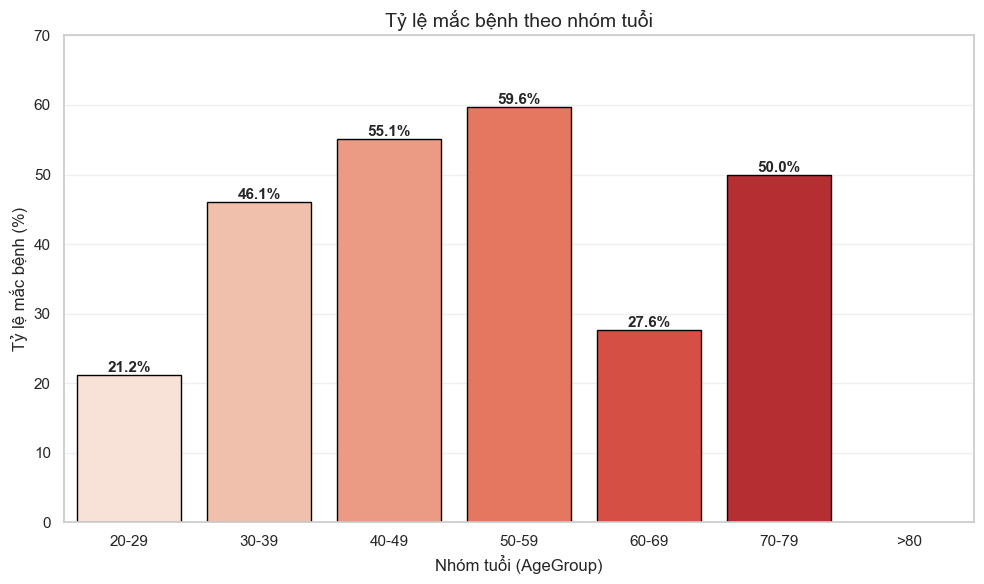

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Giả sử df_final là bộ dữ liệu sạch của bạn

# Tạo nhóm tuổi mới (phù hợp với biểu đồ mẫu: 20-29, 30-39, 40-49, 50-59, 60-69, 70-79)
age_groups = pd.cut(df_final['Age'], bins=[20, 30, 40, 50, 60, 70, 80, 81],
                    labels=['20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '>80'],
                    right=False)

# Tính tỷ lệ mắc bệnh theo nhóm tuổi
age_disease = pd.crosstab(age_groups, df_final['Outcome'], normalize='index') * 100
age_disease = age_disease[1]  # Tỷ lệ mắc bệnh (Outcome = 1)

# Vẽ biểu đồ cột tỷ lệ mắc bệnh theo nhóm tuổi
plt.figure(figsize=(10, 6))
bars = sns.barplot(x=age_disease.index, y=age_disease.values, palette='Reds', edgecolor='black')

# Thêm nhãn phần trăm lên đầu cột
for bar in bars.patches:
    bars.annotate(f'{bar.get_height():.1f}%',
                  (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                  ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Tỷ lệ mắc bệnh theo nhóm tuổi', fontsize=14)
plt.xlabel('Nhóm tuổi (AgeGroup)')
plt.ylabel('Tỷ lệ mắc bệnh (%)')
plt.ylim(0, 70)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 4.4 phân tích theo chỉ số BMI

4.4.1 Phân loại BMI và tỷ lệ mắc bệnh

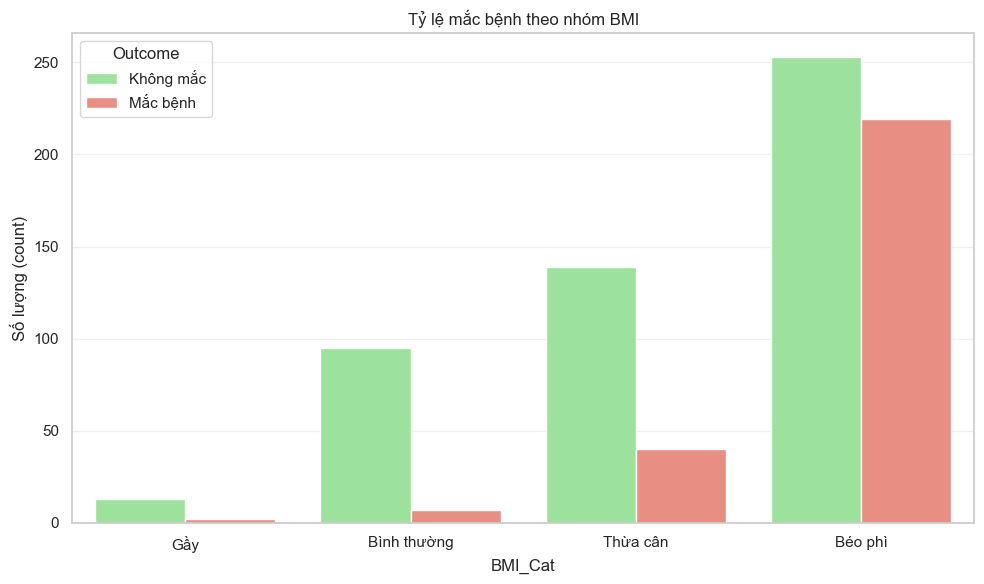

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Giả sử df_final là bộ dữ liệu sạch

# Tạo cột phân loại BMI
def classify_bmi(bmi):
    if bmi < 18.5:
        return 'Gầy'
    elif 18.5 <= bmi < 25:
        return 'Bình thường'
    elif 25 <= bmi < 30:
        return 'Thừa cân'
    else:
        return 'Béo phì'

df_final['BMI_Cat'] = df_final['BMI'].apply(classify_bmi)

# Vẽ biểu đồ cột chồng lớp
plt.figure(figsize=(10, 6))
sns.countplot(x='BMI_Cat', hue='Outcome', data=df_final, 
              palette=['lightgreen', 'salmon'], order=['Gầy', 'Bình thường', 'Thừa cân', 'Béo phì'])

plt.title('Tỷ lệ mắc bệnh theo nhóm BMI')
plt.xlabel('BMI_Cat')
plt.ylabel('Số lượng (count)')
plt.legend(title='Outcome', labels=['Không mắc', 'Mắc bệnh'])
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

4.4.2 Mối quan hệ giữa béo phì và đái tháo đường

In [49]:
import pandas as pd
import numpy as np

# Giả sử df_final là bộ dữ liệu sạch của bạn

# Tạo cột phân loại BMI
def classify_bmi(bmi):
    if bmi < 18.5:
        return 'Gầy'
    elif 18.5 <= bmi < 25:
        return 'Bình thường'
    elif 25 <= bmi < 30:
        return 'Thừa cân'
    else:
        return 'Béo phì'

df_final['BMI_Cat'] = df_final['BMI'].apply(classify_bmi)

# Tính bảng thống kê
table = df_final.groupby('BMI_Cat').agg(
    Tổng_số=('BMI', 'count'),
    Số_ca_mắc=('Outcome', 'sum'),
    BMI_trung_bình=('BMI', 'mean')
).reset_index()

table['Tỷ_lệ_mắc_(%)'] = (table['Số_ca_mắc'] / table['Tổng_số'] * 100).round(1)
table = table[['BMI_Cat', 'Tổng_số', 'Số_ca_mắc', 'Tỷ_lệ_mắc_(%)', 'BMI_trung_bình']]
table = table.reindex([3, 2, 1, 0])  # Sắp xếp: Gầy → Bình thường → Thừa cân → Béo phì

# In bảng đẹp (cho báo cáo)
print("\nBảng 4.1. Tỷ lệ mắc bệnh theo nhóm BMI\n")
print(table.to_string(index=False))

# Tính odds ratio đơn giản (so sánh béo phì vs không béo phì)
non_obese = table[table['BMI_Cat'] != 'Béo phì']
obese = table[table['BMI_Cat'] == 'Béo phì']

odds_non = (obese['Số_ca_mắc'].values[0] / (obese['Tổng_số'].values[0] - obese['Số_ca_mắc'].values[0]))
odds_obese = (non_obese['Số_ca_mắc'].sum() / (non_obese['Tổng_số'].sum() - non_obese['Số_ca_mắc'].sum()))
odds_ratio = odds_obese / odds_non if odds_non != 0 else np.inf

print(f"\nOdds ratio (béo phì so với không béo phì): {odds_ratio:.2f}")


Bảng 4.1. Tỷ lệ mắc bệnh theo nhóm BMI

    BMI_Cat  Tổng_số  Số_ca_mắc  Tỷ_lệ_mắc_(%)  BMI_trung_bình
   Thừa cân      179         40           22.3       27.500000
        Gầy       15          2           13.3        4.866667
Bình thường      102          7            6.9       22.768627
    Béo phì      472        219           46.4       36.551695

Odds ratio (béo phì so với không béo phì): 0.23


4.4.3 BMI kết hợp với các yếu tố khác

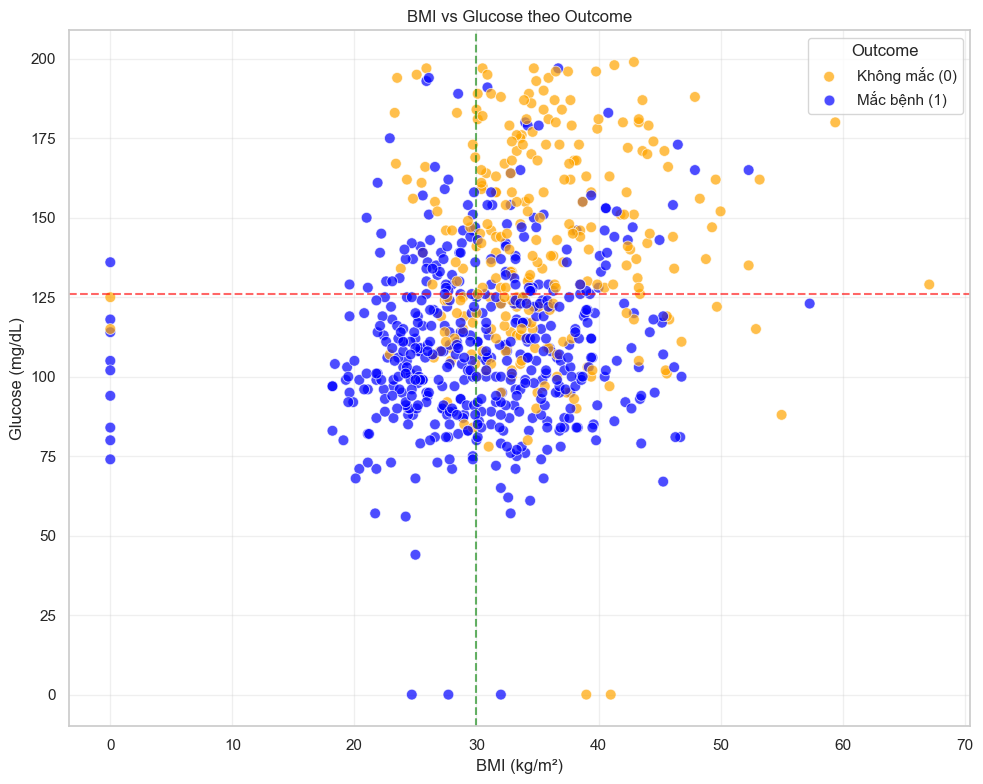

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# Giả sử df_final là bộ dữ liệu sạch

plt.figure(figsize=(10, 8))
sns.scatterplot(x='BMI', y='Glucose', data=df_final, hue='Outcome', 
                palette=['blue', 'orange'], alpha=0.7, s=60)

plt.title('BMI vs Glucose theo Outcome')
plt.xlabel('BMI (kg/m²)')
plt.ylabel('Glucose (mg/dL)')
plt.legend(title='Outcome', labels=['Không mắc (0)', 'Mắc bệnh (1)'])
plt.grid(True, alpha=0.3)

# Thêm đường tham chiếu (ngưỡng Glucose 126 và BMI 30)
plt.axhline(126, color='red', linestyle='--', alpha=0.6, label='Ngưỡng Glucose (126)')
plt.axvline(30, color='green', linestyle='--', alpha=0.6, label='Ngưỡng béo phì (30)')

plt.tight_layout()
plt.show()

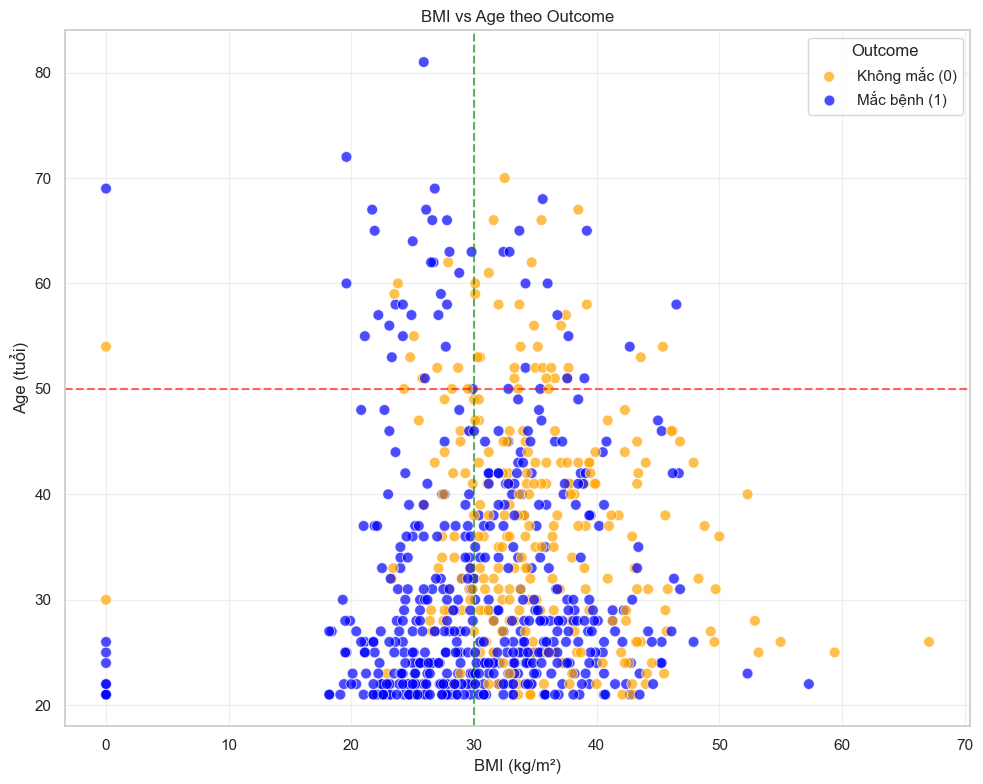

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# Giả sử df_final là bộ dữ liệu sạch

plt.figure(figsize=(10, 8))
sns.scatterplot(x='BMI', y='Age', data=df_final, hue='Outcome', 
                palette=['blue', 'orange'], alpha=0.7, s=60)

plt.title('BMI vs Age theo Outcome')
plt.xlabel('BMI (kg/m²)')
plt.ylabel('Age (tuổi)')
plt.legend(title='Outcome', labels=['Không mắc (0)', 'Mắc bệnh (1)'])
plt.grid(True, alpha=0.3)

# Thêm đường tham chiếu (ngưỡng BMI 30 và tuổi 50)
plt.axvline(30, color='green', linestyle='--', alpha=0.6, label='Ngưỡng béo phì (30)')
plt.axhline(50, color='red', linestyle='--', alpha=0.6, label='Ngưỡng tuổi cao (50)')

plt.tight_layout()
plt.show()

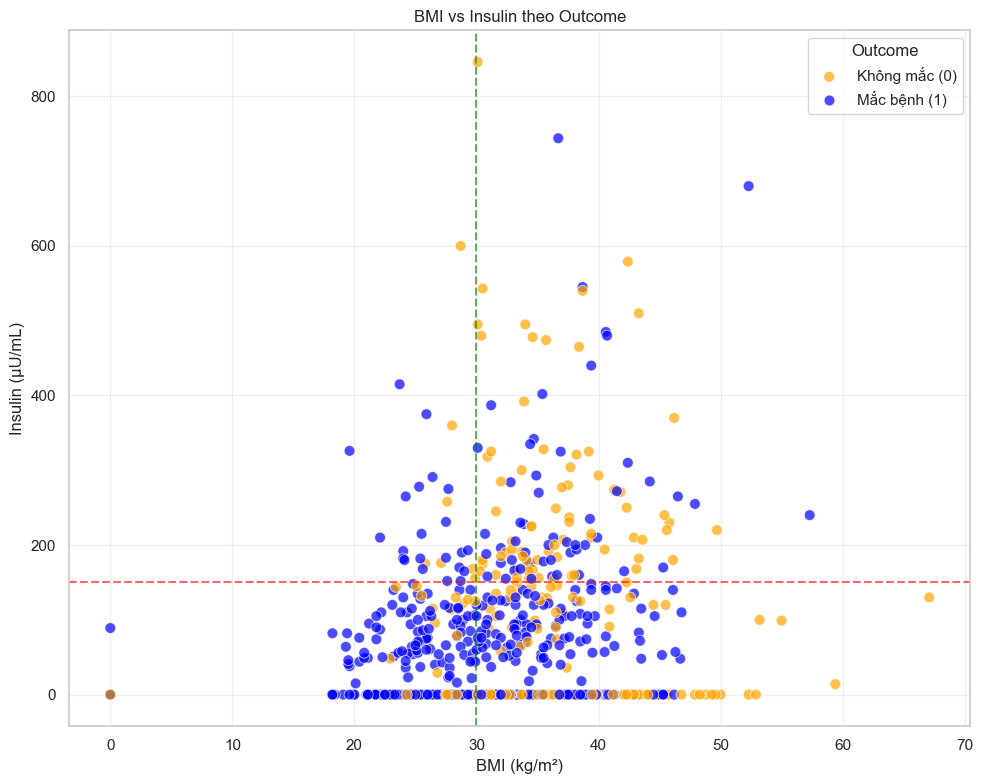

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# Giả sử df_final là bộ dữ liệu sạch

plt.figure(figsize=(10, 8))
sns.scatterplot(x='BMI', y='Insulin', data=df_final, hue='Outcome', 
                palette=['blue', 'orange'], alpha=0.7, s=60)

plt.title('BMI vs Insulin theo Outcome')
plt.xlabel('BMI (kg/m²)')
plt.ylabel('Insulin (μU/mL)')
plt.legend(title='Outcome', labels=['Không mắc (0)', 'Mắc bệnh (1)'])
plt.grid(True, alpha=0.3)

# Thêm đường tham chiếu (ngưỡng BMI 30 và Insulin cao ví dụ 150-200)
plt.axvline(30, color='green', linestyle='--', alpha=0.6, label='Ngưỡng béo phì (30)')
plt.axhline(150, color='red', linestyle='--', alpha=0.6, label='Insulin cao (150)')

plt.tight_layout()
plt.show()

## 4.5. Phân tích Glucose và Insulin
4.5.1. Phân bố bệnh theo nồng độ Glucose

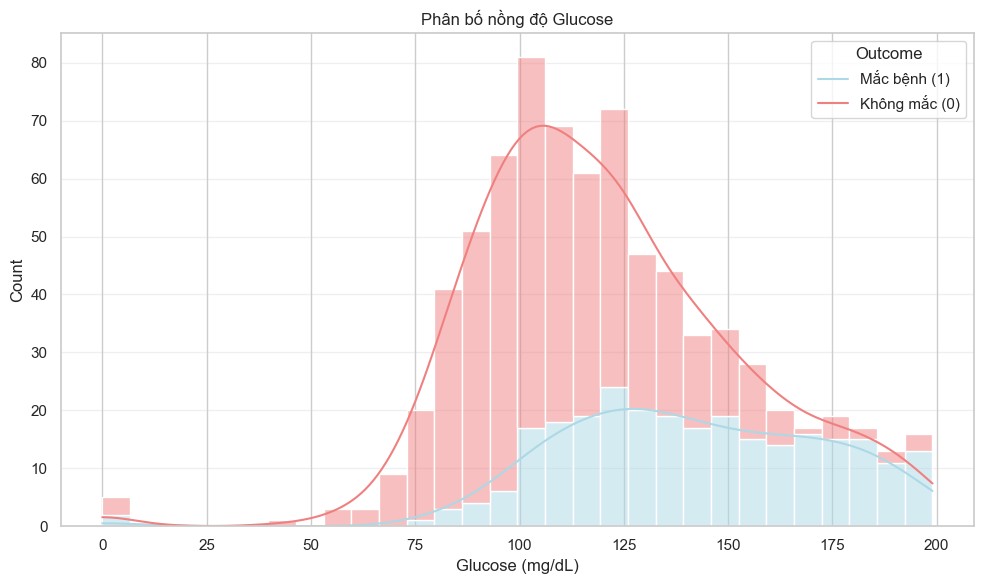

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(data=df_final, x='Glucose', hue='Outcome', multiple='stack', 
             palette=['lightcoral', 'lightblue'], bins=30, kde=True)

plt.title('Phân bố nồng độ Glucose')
plt.xlabel('Glucose (mg/dL)')
plt.ylabel('Count')
plt.legend(title='Outcome', labels=['Mắc bệnh (1)', 'Không mắc (0)'])
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

4.5.2. Mối quan hệ Glucose và Insulin

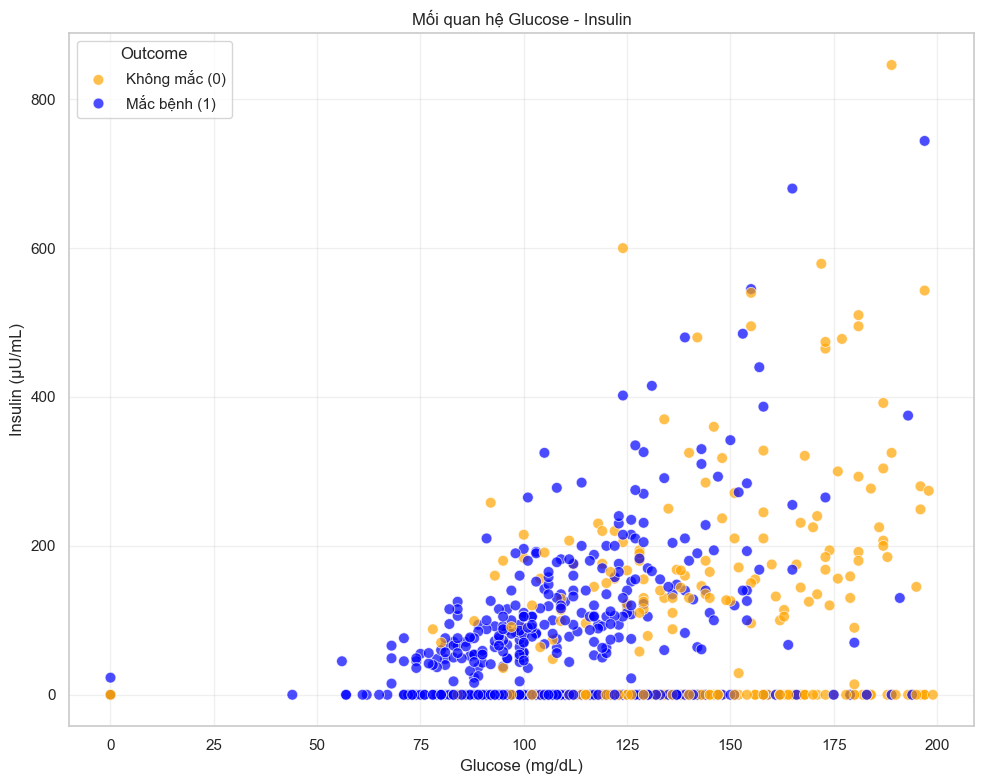

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.scatterplot(x='Glucose', y='Insulin', data=df_final, hue='Outcome', 
                palette=['blue', 'orange'], alpha=0.7, s=60)

plt.title('Mối quan hệ Glucose - Insulin')
plt.xlabel('Glucose (mg/dL)')
plt.ylabel('Insulin (μU/mL)')
plt.legend(title='Outcome', labels=['Không mắc (0)', 'Mắc bệnh (1)'])
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4.6. Phân tích yếu tố di truyền
4.6.1. Hàm pha hệ đái tháo đường và ý nghĩa


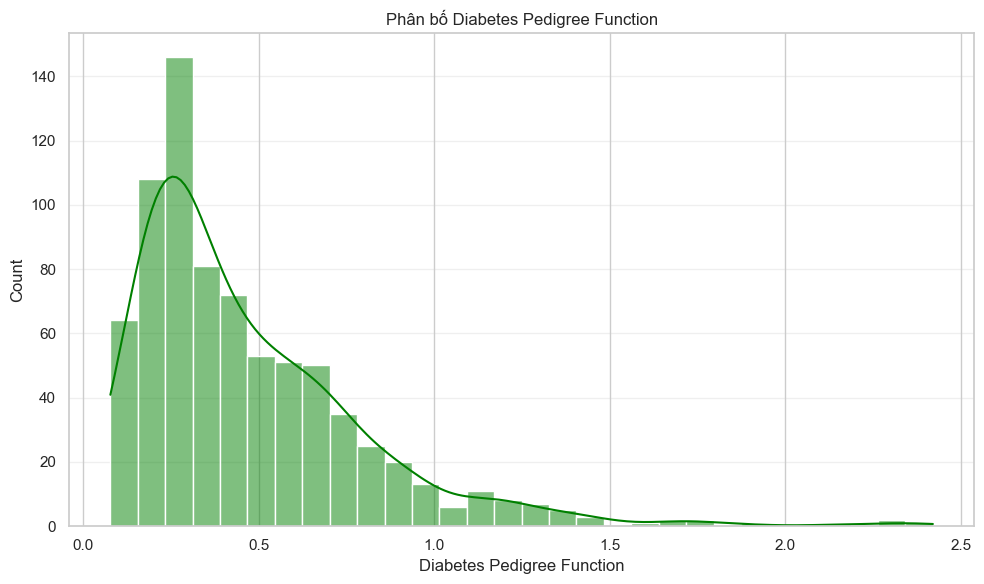

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(data=df_final, x='DiabetesPedigreeFunction', kde=True, color='green', bins=30)

plt.title('Phân bố Diabetes Pedigree Function')
plt.xlabel('Diabetes Pedigree Function')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

4.6.2. Tác động của yếu tố di truyền

C:\Users\Administrator\AppData\Local\Temp\ipykernel_11164\2361585535.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y='DiabetesPedigreeFunction', data=df_final,


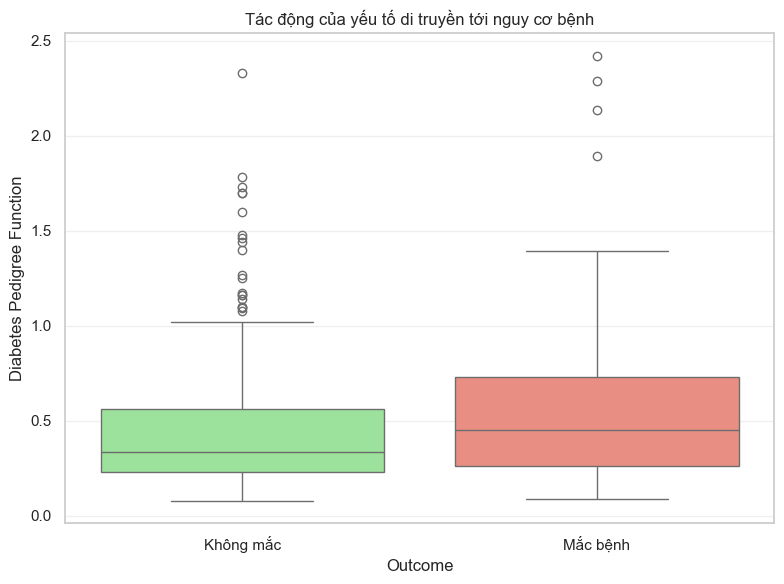

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(x='Outcome', y='DiabetesPedigreeFunction', data=df_final, 
            palette=['lightgreen', 'salmon'])

plt.title('Tác động của yếu tố di truyền tới nguy cơ bệnh')
plt.xlabel('Outcome')
plt.ylabel('Diabetes Pedigree Function')
plt.xticks([0, 1], ['Không mắc', 'Mắc bệnh'])
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

4.6.3. Kết hợp yếu tố di truyền với Glucose

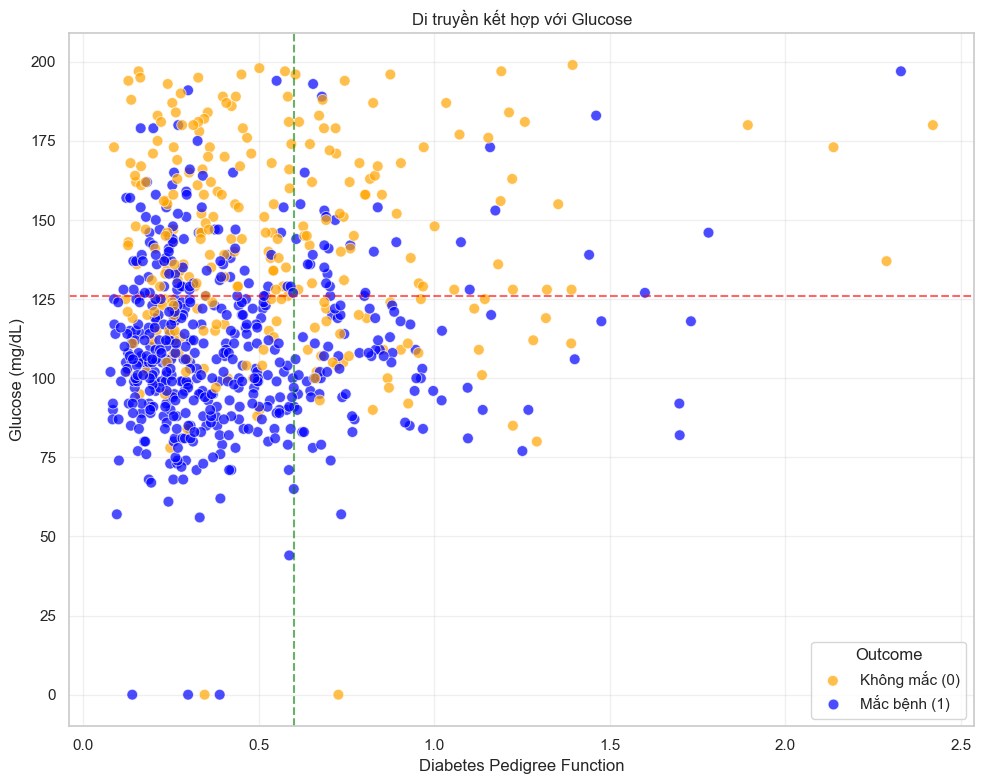

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.scatterplot(x='DiabetesPedigreeFunction', y='Glucose', data=df_final, hue='Outcome', 
                palette=['blue', 'orange'], alpha=0.7, s=60)

plt.title('Di truyền kết hợp với Glucose')
plt.xlabel('Diabetes Pedigree Function')
plt.ylabel('Glucose (mg/dL)')
plt.legend(title='Outcome', labels=['Không mắc (0)', 'Mắc bệnh (1)'])
plt.grid(True, alpha=0.3)

# Thêm đường tham chiếu (ngưỡng PDF 0.6 và Glucose 126)
plt.axvline(0.6, color='green', linestyle='--', alpha=0.6, label='Ngưỡng di truyền cao (0.6)')
plt.axhline(126, color='red', linestyle='--', alpha=0.6, label='Ngưỡng Glucose (126)')

plt.tight_layout()
plt.show()

## 4.7 theo số lần có thai


C:\Users\Administrator\AppData\Local\Temp\ipykernel_11164\1047809277.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y='Pregnancies', data=df_final,


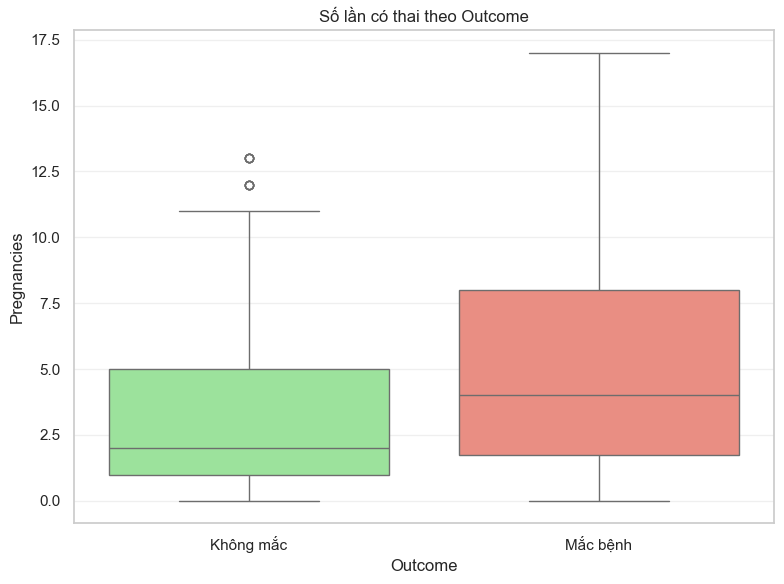

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(x='Outcome', y='Pregnancies', data=df_final, 
            palette=['lightgreen', 'salmon'])

plt.title('Số lần có thai theo Outcome')
plt.xlabel('Outcome')
plt.ylabel('Pregnancies')
plt.xticks([0, 1], ['Không mắc', 'Mắc bệnh'])
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

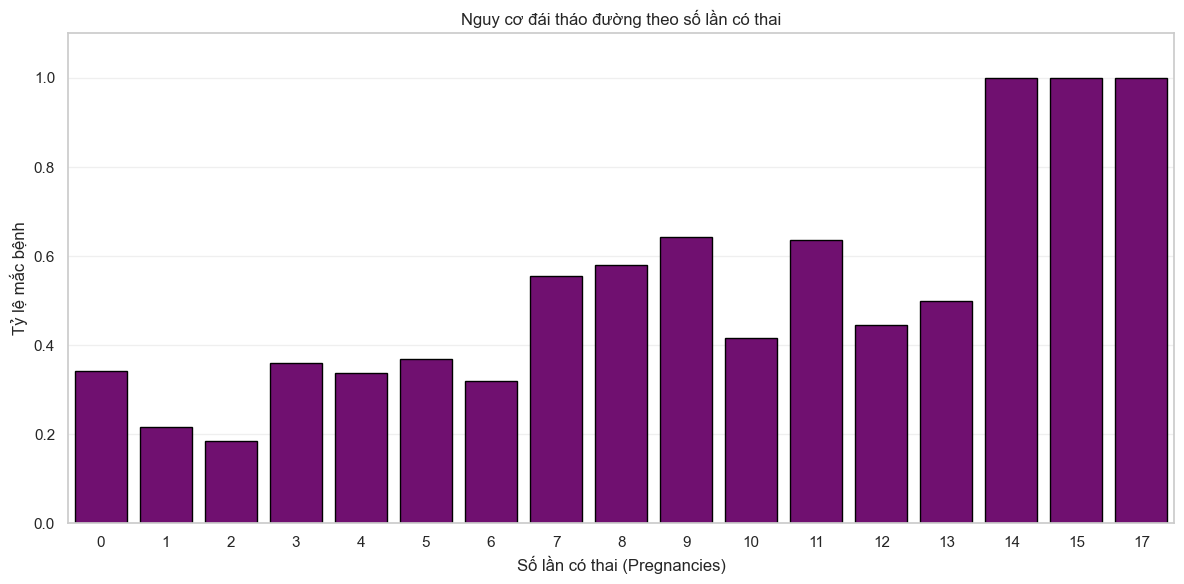

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Tính tỷ lệ mắc bệnh theo từng giá trị Pregnancies
preg_risk = df_final.groupby('Pregnancies')['Outcome'].mean().reset_index()
preg_risk.columns = ['Pregnancies', 'Tỷ lệ mắc bệnh']

# Vẽ biểu đồ cột
plt.figure(figsize=(12, 6))
sns.barplot(x='Pregnancies', y='Tỷ lệ mắc bệnh', data=preg_risk, color='purple', edgecolor='black')

plt.title('Nguy cơ đái tháo đường theo số lần có thai')
plt.xlabel('Số lần có thai (Pregnancies)')
plt.ylabel('Tỷ lệ mắc bệnh')
plt.ylim(0, 1.1)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# CHƯƠNG 5: PHÂN TÍCH TƯƠNG QUAN VÀ MỐI QUAN HỆ

Import các thư viện cần

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import chi2, mutual_info_classif
from sklearn.metrics import roc_curve, auc
from statsmodels.stats.outliers_influence import variance_inflation_factor

Đọc dữ liệu

In [21]:
# ── Load và rename dữ liệu ──
columns = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", 
           "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]

try:
    df = pd.read_csv("pima_diabetes_cleaned.csv", header=None, names=columns)
    print("Load dữ liệu thành công! Shape:", df.shape)
    print(df.head(3))  # kiểm tra nhanh 3 dòng đầu
except FileNotFoundError:
    print("LỖI: Không tìm thấy file 'pima_diabetes_cleaned.csv'. Kiểm tra đường dẫn hoặc tên file!")
    # Nếu file ở chỗ khác, thay bằng đường dẫn đầy đủ, ví dụ:
    # df = pd.read_csv(r"C:\Users\YourName\Downloads\pima_diabetes_cleaned.csv", ...)
except Exception as e:
    print("Lỗi khi load file:", e)

Load dữ liệu thành công! Shape: (769, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0  Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI   
1            6    148.0           72.0           35.0    169.5  33.6   
2            1     85.0           66.0           29.0    102.5  26.6   

   DiabetesPedigreeFunction  Age  Outcome  
0  DiabetesPedigreeFunction  Age  Outcome  
1                     0.627   50        1  
2                     0.351   31        0  


In [22]:
# Rename sang tiếng Việt
vn_columns = {
    "Pregnancies": "Số lần mang thai",
    "Glucose": "Glucose",
    "BloodPressure": "Huyết áp",
    "SkinThickness": "Độ dày da",
    "Insulin": "Insulin",
    "BMI": "BMI",
    "DiabetesPedigreeFunction": "Chỉ số di truyền (DPF)",
    "Age": "Tuổi",
    "Outcome": "Kết quả",
}
df_vn = df.rename(columns=vn_columns)

# VẼ BIỂU ĐỒ

5.1. Ma trận tương quan


Ma trận tương quan (mẫu):
                        Số lần mang thai  Glucose  Huyết áp  Độ dày da  \
Số lần mang thai                    1.00     0.13      0.21       0.09   
Glucose                             0.13     1.00      0.23       0.23   
Huyết áp                            0.21     0.23      1.00       0.20   
Độ dày da                           0.09     0.23      0.20       1.00   
Insulin                             0.06     0.49      0.07       0.20   
BMI                                 0.02     0.24      0.29       0.57   
Chỉ số di truyền (DPF)             -0.03     0.14     -0.00       0.11   
Tuổi                                0.54     0.27      0.33       0.13   
Kết quả                             0.22     0.50      0.17       0.30   

                        Insulin   BMI  Chỉ số di truyền (DPF)  Tuổi  Kết quả  
Số lần mang thai           0.06  0.02                   -0.03  0.54     0.22  
Glucose                    0.49  0.24                    0.14  0.27     0.

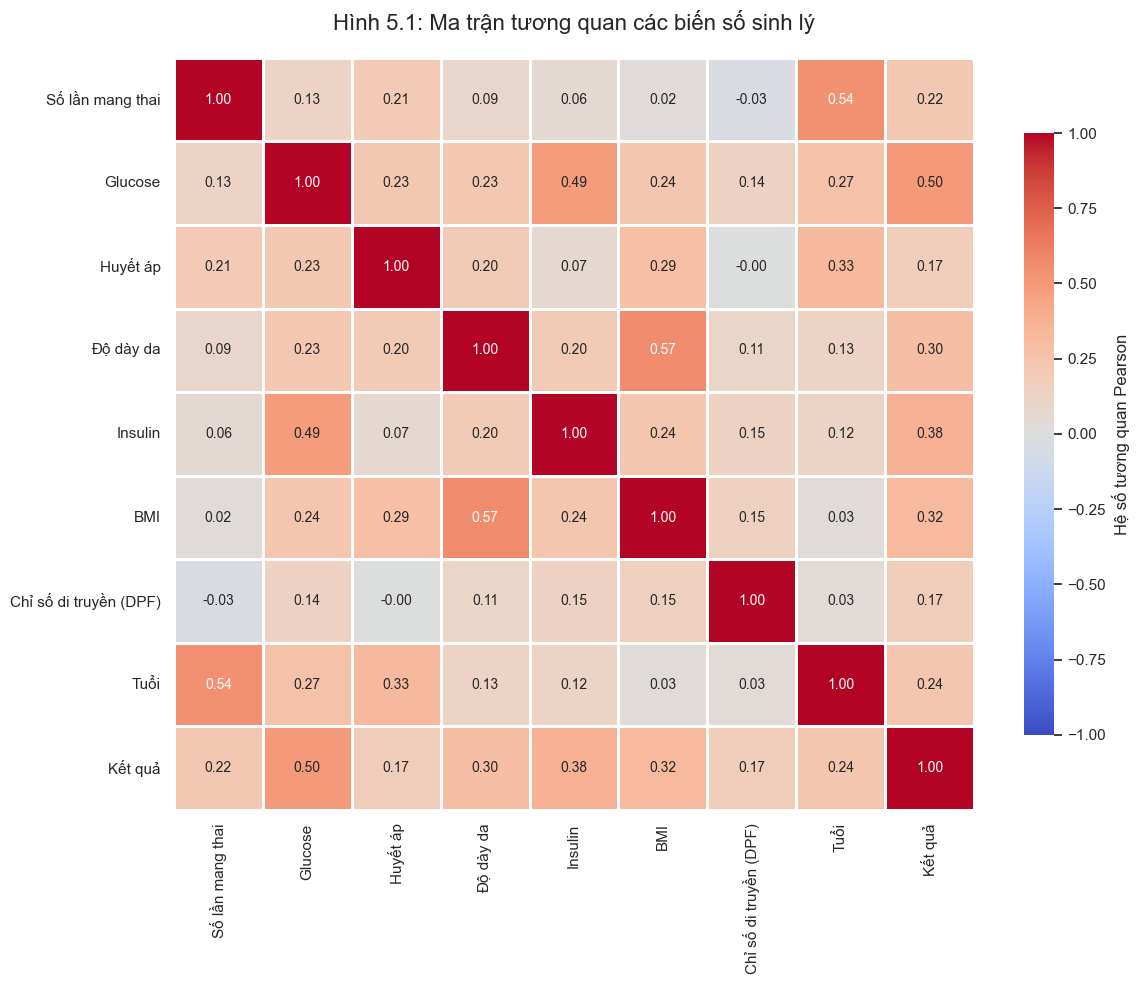

In [25]:


# ── Vẽ heatmap ──
sns.set(style="whitegrid")
plt.figure(figsize=(12, 10))

corr = df_vn.corr(numeric_only=True)

if corr.empty or corr.isnull().all().all():
    print("\nLỖI: Ma trận tương quan vẫn rỗng! Nguyên nhân có thể:")
    print("- Tất cả cột là chuỗi (object) → kiểm tra df.dtypes")
    print("- Dữ liệu có giá trị không chuyển được thành số → thử ép kiểu")
    print("Gợi ý: Chạy df = df.apply(pd.to_numeric, errors='coerce') rồi dropna()")
else:
    print("\nMa trận tương quan (mẫu):")
    print(corr.round(2))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    center=0,
    linewidths=0.8,
    annot_kws={'size': 10},
    cbar_kws={'label': 'Hệ số tương quan Pearson', 'shrink': 0.8}
)

plt.title("Hình 5.1: Ma trận tương quan các biến số sinh lý", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

5.2. Phân tích Glucose

C:\Users\Administrator\AppData\Local\Temp\ipykernel_16472\2981407175.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Kết quả", y="Glucose", data=df_vn, ax=ax1, palette="Set2")


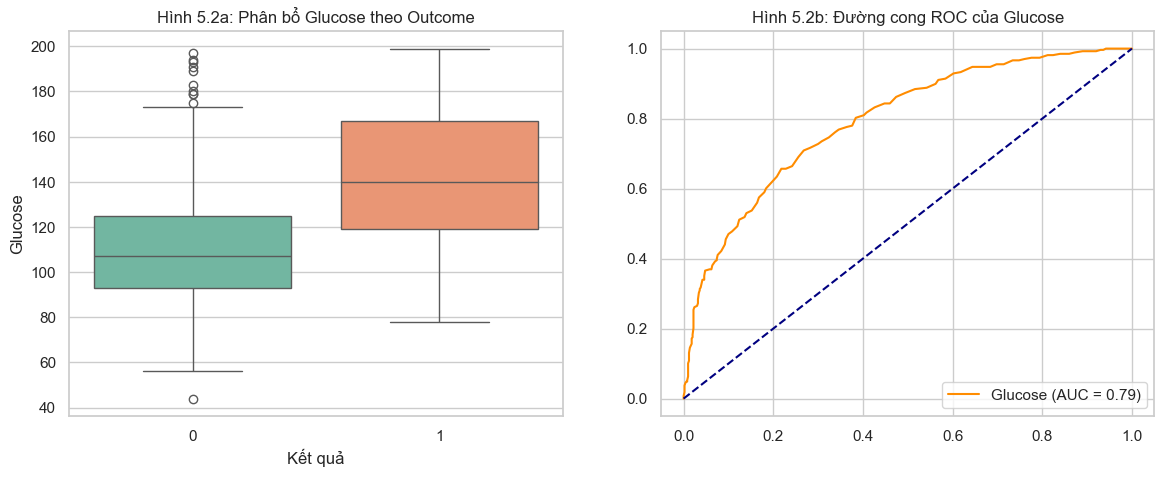

In [26]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x="Kết quả", y="Glucose", data=df_vn, ax=ax1, palette="Set2")
ax1.set_title("Hình 5.2a: Phân bổ Glucose theo Outcome")

fpr, tpr, _ = roc_curve(df_vn["Kết quả"], df_vn["Glucose"])
roc_auc = auc(fpr, tpr)
ax2.plot(fpr, tpr, color="darkorange", label=f"Glucose (AUC = {roc_auc:.2f})")
ax2.plot([0, 1], [0, 1], color="navy", linestyle="--")
ax2.set_title("Hình 5.2b: Đường cong ROC của Glucose")
ax2.legend(loc="lower right")
plt.show()

5.3, 5.4, 5.5. Các cặp biến quan trọng


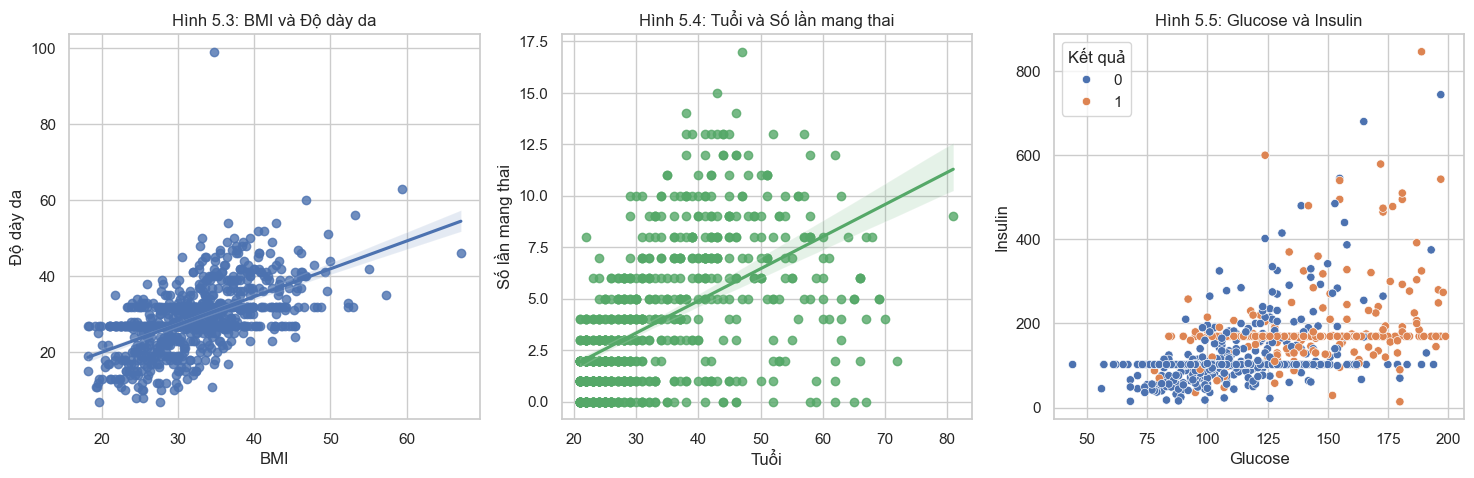

In [27]:
plt.figure(figsize=(18, 5))
plt.subplot(131)
sns.regplot(x="BMI", y="Độ dày da", data=df_vn)
plt.title("Hình 5.3: BMI và Độ dày da")
plt.subplot(132)
sns.regplot(x="Tuổi", y="Số lần mang thai", data=df_vn, color="g")
plt.title("Hình 5.4: Tuổi và Số lần mang thai")
plt.subplot(133)
sns.scatterplot(x="Glucose", y="Insulin", hue="Kết quả", data=df_vn)
plt.title("Hình 5.5: Glucose và Insulin")
plt.show()

5.1 & 5.2. Tầm quan trọng

C:\Users\Administrator\AppData\Local\Temp\ipykernel_16472\1926278164.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=scores_mi, y=X.columns, palette="viridis")
C:\Users\Administrator\AppData\Local\Temp\ipykernel_16472\1926278164.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf.feature_importances_, y=X.columns, palette="magma")


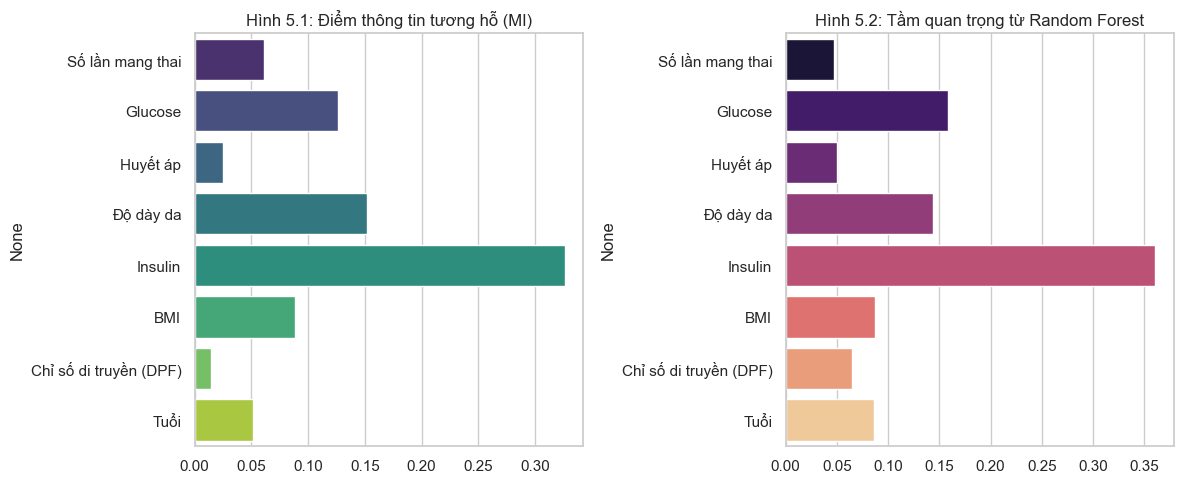

In [28]:

X = df_vn.drop("Kết quả", axis=1)
y = df_vn["Kết quả"]
scores_mi = mutual_info_classif(X, y, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42).fit(X, y)

plt.figure(figsize=(12, 5))
plt.subplot(121)
sns.barplot(x=scores_mi, y=X.columns, palette="viridis")
plt.title("Hình 5.1: Điểm thông tin tương hỗ (MI)")

plt.subplot(122)
sns.barplot(x=rf.feature_importances_, y=X.columns, palette="magma")
plt.title("Hình 5.2: Tầm quan trọng từ Random Forest")
plt.tight_layout()
plt.show()

5.6 - Biểu đồ Chi-square

Bảng Chi-square chi tiết 5.6.1:
               Biến số  Chi-square      p-value
               Insulin 6107.908339 0.000000e+00
               Glucose 1439.168619 0.000000e+00
             Độ dày da  181.546053 2.227728e-41
                  Tuổi  181.303689 2.516388e-41
      Số lần mang thai  111.519691 4.552610e-26
                   BMI  111.489994 4.621319e-26
              Huyết áp   47.267258 6.193825e-12
Chỉ số di truyền (DPF)    5.392682 2.022137e-02


C:\Users\Administrator\AppData\Local\Temp\ipykernel_16472\734118997.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Chi-square", y="Biến số", data=chi2_data, palette="Blues_r")


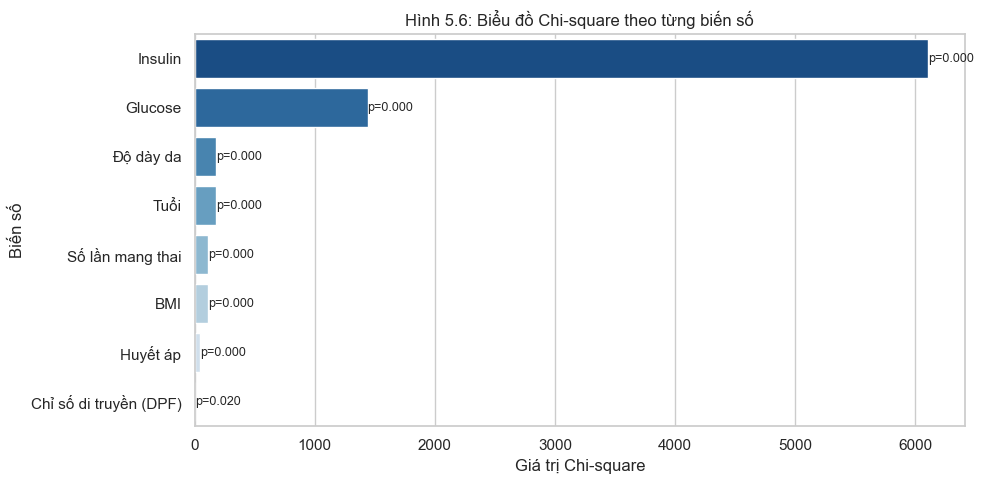


Bảng 5.1: Điểm thông tin tương hỗ (Mutual Information)
               Biến số  Mutual Information
               Insulin            0.325872
             Độ dày da            0.152275
               Glucose            0.126140
                   BMI            0.088895
      Số lần mang thai            0.060985
                  Tuổi            0.051395
              Huyết áp            0.025256
Chỉ số di truyền (DPF)            0.014590

Bảng 5.2: Tầm quan trọng của đặc trưng (Random Forest)
               Biến số  Importance
               Insulin    0.360962
               Glucose    0.158366
             Độ dày da    0.143416
                   BMI    0.087686
                  Tuổi    0.086385
Chỉ số di truyền (DPF)    0.065001
              Huyết áp    0.050493
      Số lần mang thai    0.047691


In [29]:

from sklearn.feature_selection import chi2
import pandas as pd

chi2_scores, chi2_pvals = chi2(X, y)
chi2_data = pd.DataFrame({
    "Biến số": X.columns,
    "Chi-square": chi2_scores,
    "p-value": chi2_pvals
}).sort_values("Chi-square", ascending=False)

print("Bảng Chi-square chi tiết 5.6.1:")
print(chi2_data.to_string(index=False))

plt.figure(figsize=(10, 5))
sns.barplot(x="Chi-square", y="Biến số", data=chi2_data, palette="Blues_r")
for i, (val, pval) in enumerate(zip(chi2_data["Chi-square"], chi2_data["p-value"])):
    plt.text(val + 0.2, i, f"p={pval:.3f}", va="center", fontsize=9)
plt.title("Hình 5.6: Biểu đồ Chi-square theo từng biến số")
plt.xlabel("Giá trị Chi-square")
plt.tight_layout()
plt.show()

print("\nBảng 5.1: Điểm thông tin tương hỗ (Mutual Information)")
mi_table = pd.DataFrame({
    "Biến số": X.columns,
    "Mutual Information": scores_mi
}).sort_values("Mutual Information", ascending=False).reset_index(drop=True)
print(mi_table.to_string(index=False))
print("\nBảng 5.2: Tầm quan trọng của đặc trưng (Random Forest)")
rf_table = pd.DataFrame({
    "Biến số": X.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False).reset_index(drop=True)
print(rf_table.to_string(index=False))

5.8. Hệ số VIF (Đa cộng tuyến)

In [30]:

vif_data = pd.DataFrame()
vif_data["Biến số"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i) for i in range(len(X.columns))
]
print("\nBảng 5.3: Hệ số phóng đại phương sai (VIF)")
print(vif_data.sort_values(by="VIF", ascending=False))


Bảng 5.3: Hệ số phóng đại phương sai (VIF)
                  Biến số        VIF
5                     BMI  34.623697
2                Huyết áp  32.327937
1                 Glucose  23.003682
3               Độ dày da  17.724356
7                    Tuổi  14.323395
4                 Insulin   4.774325
0        Số lần mang thai   3.272988
6  Chỉ số di truyền (DPF)   3.153224


5.8 - Biểu đồ VIF

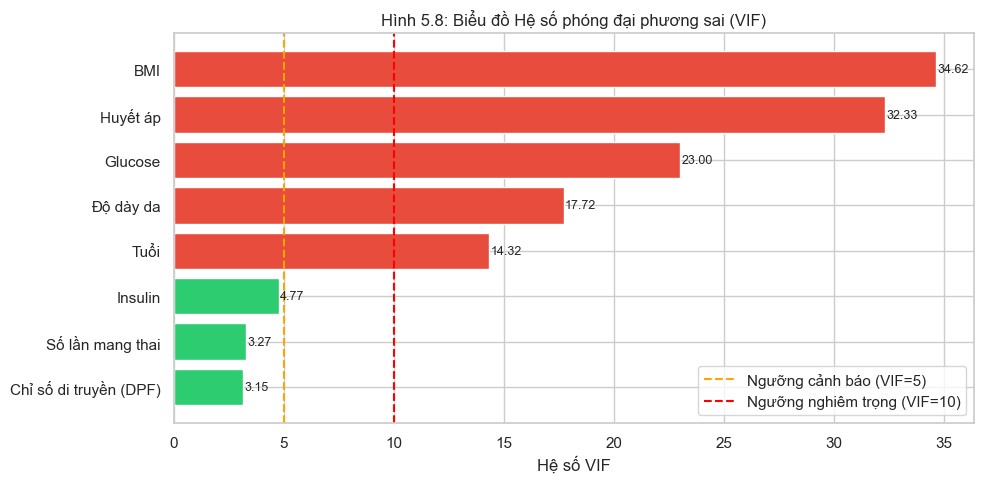

In [31]:

vif_sorted = vif_data.sort_values(by="VIF", ascending=True)

plt.figure(figsize=(10, 5))
colors = ["#e74c3c" if v > 5 else "#2ecc71" for v in vif_sorted["VIF"]]
bars = plt.barh(vif_sorted["Biến số"], vif_sorted["VIF"], color=colors)
plt.axvline(x=5, color="orange", linestyle="--", label="Ngưỡng cảnh báo (VIF=5)")
plt.axvline(x=10, color="red", linestyle="--", label="Ngưỡng nghiêm trọng (VIF=10)")
for bar, val in zip(bars, vif_sorted["VIF"]):
    plt.text(val + 0.05, bar.get_y() + bar.get_height()/2,
             f"{val:.2f}", va="center", fontsize=9)
plt.xlabel("Hệ số VIF")
plt.title("Hình 5.8: Biểu đồ Hệ số phóng đại phương sai (VIF)")
plt.legend()
plt.tight_layout()
plt.show()